In [1]:
import sys
sys.path.append("../")
from src.simulation import *




In [22]:
# %% ─── Imports & Setup ───────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from dataclasses import dataclass, field
from scipy.optimize import minimize_scalar
from scipy.interpolate import interp1d

# %% ─── Parameters & Environment ──────────────────────────────────

@dataclass
class Params:
    ALPHA: float = 0.33
    DELTA: float = 0.05
    R: float = 0.02
    KAPPA: float = 0.5
    BETA: float = field(init=False)

    def __post_init__(self):
        self.BETA = 1 / (1 + self.R)

p = Params()

def production(z, k):
    return z * max(k, 1e-8) ** p.ALPHA

def dividend(z, k, i):
    return production(z, k) - i

def next_capital(k, i):
    return (1 - p.DELTA) * k + i

# %% ─── Grids ─────────────────────────────────────────────────────

z_grid = np.array([1.0])          # deterministic for testing
k_grid = np.linspace(0.25, 20, 80)
i_grid = np.linspace(0.0, 3.5, 60)

Nz, Nk, Ni = z_grid.size, k_grid.size, i_grid.size
print(f"Grid: {Nz} x {Nk} x {Ni} = {Nz*Nk*Ni:,} points")

# %% ─── Rational Benchmark (VFI) ─────────────────────────────────

v_rat = np.zeros(Nk)
pol_rat = np.zeros(Nk)  # stores optimal i(k)

for ik, k in enumerate(k_grid):
    v_rat[ik] = production(1.0, k) / p.R

ev_func = interp1d(k_grid, v_rat, kind='linear', fill_value='extrapolate')

for _ in range(500):
    v_new = np.zeros(Nk)
    pol_new = np.zeros(Nk)
    ev_func = interp1d(k_grid, v_rat, kind='linear', fill_value='extrapolate')

    for ik, k in enumerate(k_grid):
        def obj(i):
            kp = next_capital(k, i)
            if kp < k_grid[0]:
                return 1e10
            return -(dividend(1.0, k, i) + p.BETA * ev_func(kp))

        i_max = min(production(1.0, k), i_grid[-1])  # can't invest more than output
        res = minimize_scalar(obj, bounds=(0, i_max), method='bounded')
        v_new[ik] = -res.fun
        pol_new[ik] = res.x

    if np.max(np.abs(v_new - v_rat)) < 1e-8:
        break
    v_rat = v_new
    pol_rat = pol_new

# Build Q* on the grid for reference
Q_true = np.zeros((Nk, Ni))
ev_func = interp1d(k_grid, v_rat, kind='linear', fill_value='extrapolate')
for ik, k in enumerate(k_grid):
    for ii, iv in enumerate(i_grid):
        kp = next_capital(k, iv)
        kp_clipped = np.clip(kp, k_grid[0], k_grid[-1])
        Q_true[ik, ii] = dividend(1.0, k, iv) + p.BETA * ev_func(kp_clipped)

print("VFI converged.")
k_ss_idx = np.argmin(np.abs(pol_rat - p.DELTA * k_grid))
print(f"Steady state: k* ≈ {k_grid[k_ss_idx]:.2f}, i* ≈ {pol_rat[k_ss_idx]:.3f}")


Grid: 1 x 80 x 60 = 4,800 points
VFI converged.
Steady state: k* ≈ 10.00, i* ≈ 0.500


In [5]:
gp_config = GPBeliefConfig()

z_grid = np.linspace(0.05, 1.5, 120)
k_grid = np.linspace(0.25, 20.0, 120)
i_grid = np.linspace(0.0, 10, 120)

gp_belief = GridGPBelief(cfg=gp_config, z_grid=z_grid, k_grid=k_grid, i_grid=i_grid)

Steady state: k* = 9.949, i* = 0.497, d* = 1.631


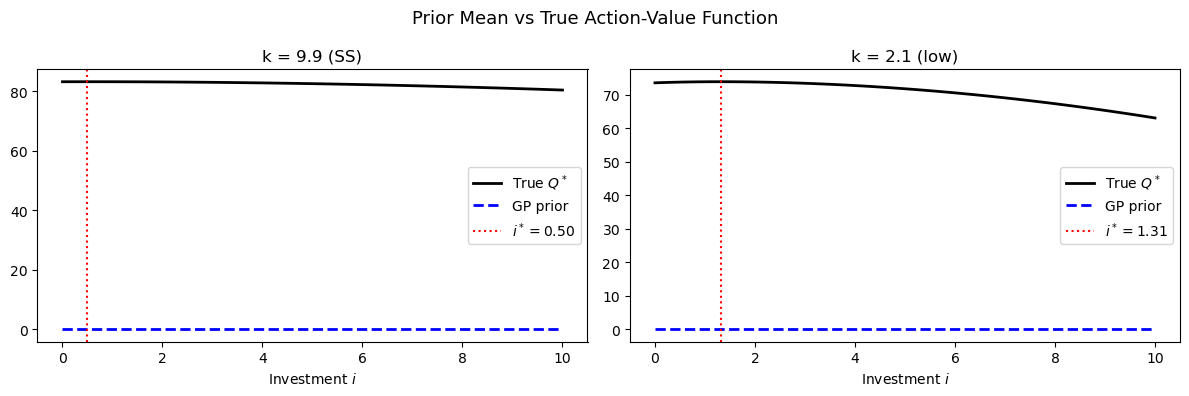

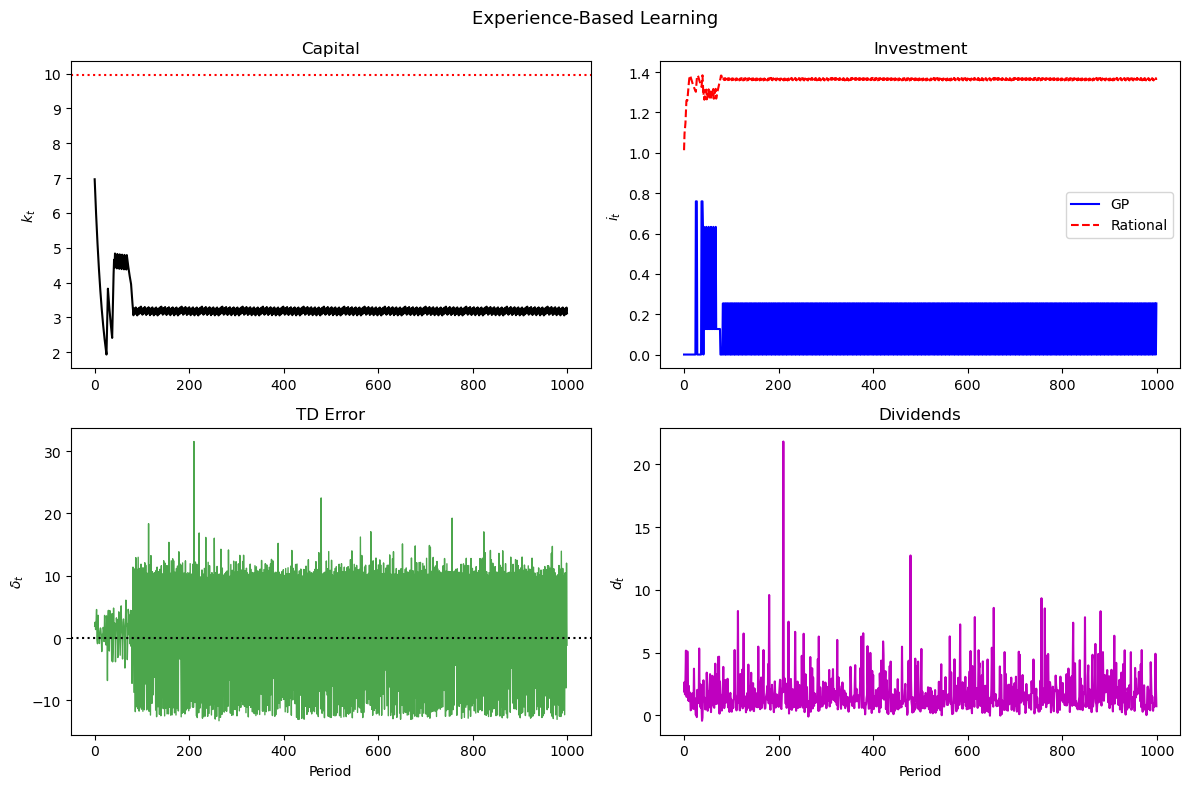

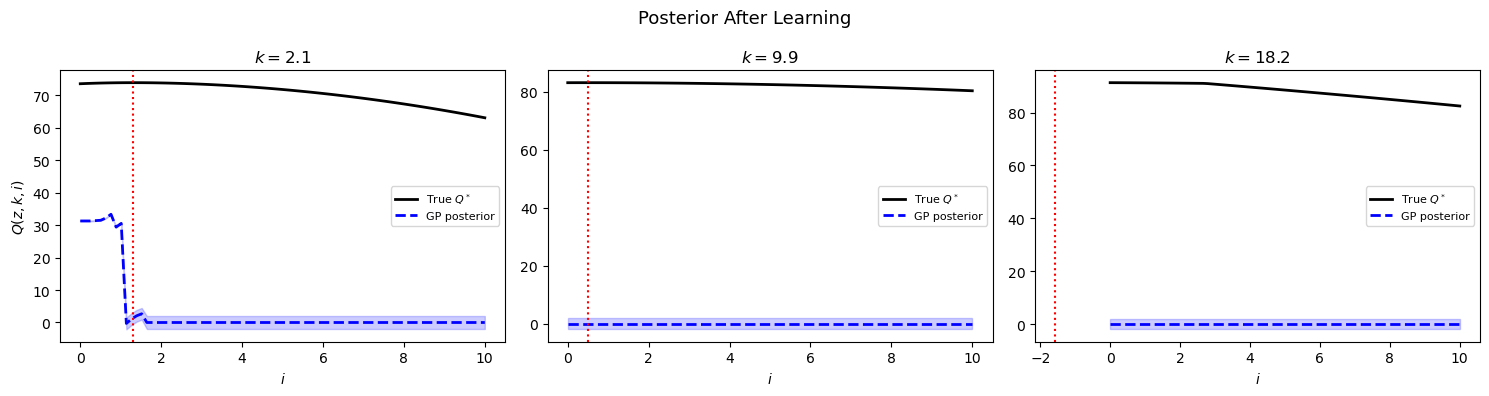

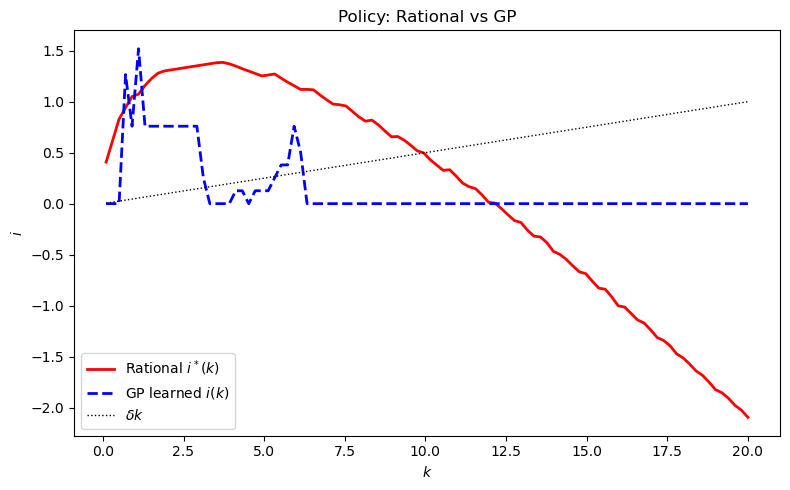

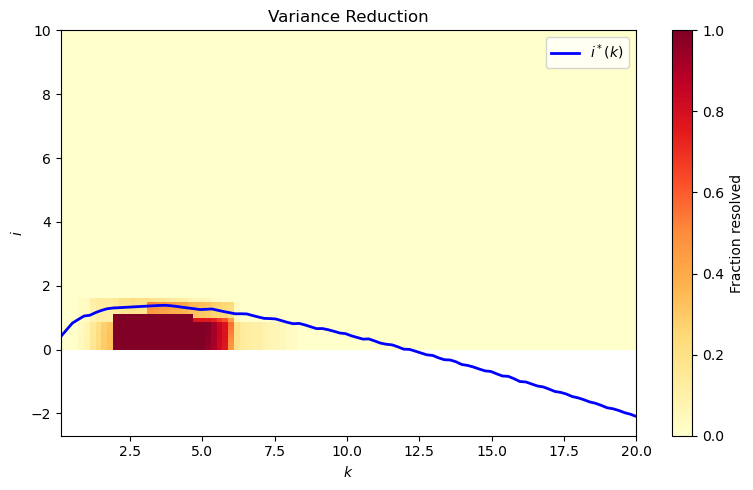

In [19]:
# %% ─── Imports ───────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from src.simulation import InvestmentParameters, InvestmentEnvironment, RationalInvestment

# %% ─── Solve Rational Benchmark ─────────────────────────────────

p = InvestmentParameters(KAPPA=0.5, SIGMA_EPS=0.0, DELTA=0.05, R=0.02)
env = InvestmentEnvironment(p)
rat = RationalInvestment(p).fit()

k_ss = rat.fixed_point()
i_ss = p.DELTA * k_ss
d_ss = env.dividend(1.0, k_ss, i_ss)
print(f"Steady state: k* = {k_ss:.3f}, i* = {i_ss:.3f}, d* = {d_ss:.3f}")

# %% ─── Build True Q* on Grid ────────────────────────────────────

z_grid = rat.z_grid
k_grid = rat.k_grid
i_grid = np.linspace(0.0, 10, 80)

from scipy.interpolate import interp1d
ev_func = interp1d(k_grid, rat.v[0, :], kind='linear', fill_value='extrapolate')

Q_true = np.zeros((k_grid.size, i_grid.size))
for ik, k in enumerate(k_grid):
    for ii, iv in enumerate(i_grid):
        kp = (1 - p.DELTA) * k + iv
        kp_clip = np.clip(kp, k_grid[0], k_grid[-1])
        Q_true[ik, ii] = env.dividend(1.0, k, iv) + p.BETA * ev_func(kp_clip)

# rational i*(k) on our grid
pol_rat = np.array([rat.policy_kprime(1.0, k) - (1 - p.DELTA) * k for k in k_grid])

# %% ─── Initialize GP ────────────────────────────────────────────

cfg = GPBeliefConfig(
    sigma0=2.0,
    lz=1,
    lk=10.0,
    li=5.0,
    band_z=1,
    band_k=6,
    band_i=6,
    var_floor=0.01,
)

gp = GridGPBelief(z_grid, k_grid, i_grid, cfg)

# myopic prior: current dividend + discounted steady-state dividend
def q_prior(z, k, i):
    return env.dividend(z, k, i) + p.BETA / (1 - p.BETA) * d_ss

# gp.initialize_prior_mean(q_prior)

# %% ─── Plot 1: Prior Mean vs True Q* ────────────────────────────

k_ss_idx = int(np.argmin(np.abs(k_grid - k_ss)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, ik, label in [(axes[0], k_ss_idx, f'k = {k_grid[k_ss_idx]:.1f} (SS)'),
                       (axes[1], 10, f'k = {k_grid[10]:.1f} (low)')]:
    ax.plot(i_grid, Q_true[ik, :], 'k-', lw=2, label='True $Q^*$')
    ax.plot(i_grid, gp.mu[0, ik, :], 'b--', lw=2, label='GP prior')
    ax.axvline(pol_rat[ik], color='r', ls=':', label=f'$i^* = {pol_rat[ik]:.2f}$')
    ax.set_xlabel('Investment $i$'); ax.set_title(label); ax.legend()
plt.suptitle('Prior Mean vs True Action-Value Function', fontsize=13)
plt.tight_layout(); plt.show()

# %% ─── Simulate Experience Learning ─────────────────────────────

np.random.seed(42)
T = 1000
sigma_shock = 0.7

z_t, k_t = 1.0, k_ss * 0.7
hist = {key: [] for key in ['k', 'i_gp', 'i_rat', 'td', 'd']}

for t in range(T):
    iz = gp.z_idx(z_t)
    ik = gp.k_idx(k_t)

    # GP greedy
    ii_best = gp.best_i_idx(iz, ik)
    i_gp = i_grid[ii_best]

    # rational benchmark at same k
    i_rat = rat.policy_kprime(z_t, k_t) - (1 - p.DELTA) * k_t

    # step
    d_t = env.dividend(z_t, k_t, i_gp)
    k_next = np.clip((1 - p.DELTA) * k_t + i_gp, k_grid[0], k_grid[-1])
    z_next = np.exp(np.random.normal(0, sigma_shock))

    # greedy at outcome
    iz_n = gp.z_idx(z_next)
    ik_n = gp.k_idx(k_next)
    ii_n = gp.best_i_idx(iz_n, ik_n)
    i_next = i_grid[ii_n]

    # TD error
    td = d_t + p.BETA * gp.mu[iz_n, ik_n, ii_n] - gp.mu[iz, ik, ii_best]

    gp.update_experience(
        beta=p.BETA,
        z_dec=z_t, k_dec=k_t, i_dec=i_gp,
        z_out=z_next, k_out=k_next, i_out=i_next,
        td_error=td,
    )

    hist['k'].append(k_t)
    hist['i_gp'].append(i_gp)
    hist['i_rat'].append(i_rat)
    hist['td'].append(td)
    hist['d'].append(d_t)

    z_t, k_t = z_next, k_next

hist = {k: np.array(v) for k, v in hist.items()}

# %% ─── Plot 2: Learning Dynamics ────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(hist['k'], 'k-', lw=1.5)
axes[0,0].axhline(k_ss, color='r', ls=':'); axes[0,0].set_ylabel('$k_t$'); axes[0,0].set_title('Capital')

axes[0,1].plot(hist['i_gp'], 'b-', lw=1.5, label='GP'); axes[0,1].plot(hist['i_rat'], 'r--', lw=1.5, label='Rational')
axes[0,1].set_ylabel('$i_t$'); axes[0,1].set_title('Investment'); axes[0,1].legend()

axes[1,0].plot(hist['td'], 'g-', lw=1, alpha=0.7); axes[1,0].axhline(0, color='k', ls=':')
axes[1,0].set_ylabel('$\\delta_t$'); axes[1,0].set_xlabel('Period'); axes[1,0].set_title('TD Error')

axes[1,1].plot(hist['d'], 'm-', lw=1.5)
axes[1,1].set_ylabel('$d_t$'); axes[1,1].set_xlabel('Period'); axes[1,1].set_title('Dividends')

plt.suptitle('Experience-Based Learning', fontsize=13); plt.tight_layout(); plt.show()

# %% ─── Plot 3: Posterior vs True Q* ─────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, ik in enumerate([10, k_ss_idx, len(k_grid)-10]):
    ax = axes[idx]
    ax.plot(i_grid, Q_true[ik, :], 'k-', lw=2, label='True $Q^*$')
    ax.plot(i_grid, gp.mu[0, ik, :], 'b--', lw=2, label='GP posterior')
    std = np.sqrt(gp.var[0, ik, :])
    ax.fill_between(i_grid, gp.mu[0,ik,:]-std, gp.mu[0,ik,:]+std, alpha=0.2, color='blue')
    ax.axvline(pol_rat[ik], color='r', ls=':')
    ax.set_xlabel('$i$'); ax.set_title(f'$k = {k_grid[ik]:.1f}$')
    if idx == 0: ax.set_ylabel('$Q(z,k,i)$')
    ax.legend(fontsize=8)
plt.suptitle('Posterior After Learning', fontsize=13); plt.tight_layout(); plt.show()

# %% ─── Plot 4: Policy Comparison ────────────────────────────────

gp_pol = np.array([i_grid[gp.best_i_idx(0, ik)] for ik in range(len(k_grid))])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_grid, pol_rat, 'r-', lw=2, label='Rational $i^*(k)$')
ax.plot(k_grid, gp_pol, 'b--', lw=2, label='GP learned $i(k)$')
ax.plot(k_grid, p.DELTA * k_grid, 'k:', lw=1, label='$\\delta k$')
ax.set_xlabel('$k$'); ax.set_ylabel('$i$'); ax.set_title('Policy: Rational vs GP'); ax.legend()
plt.tight_layout(); plt.show()

# %% ─── Plot 5: Variance Reduction ───────────────────────────────

var_red = 1.0 - gp.var[0, :, :] / cfg.sigma0**2

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(var_red.T, origin='lower', aspect='auto',
               extent=[k_grid[0], k_grid[-1], i_grid[0], i_grid[-1]],
               cmap='YlOrRd', vmin=0, vmax=1)
ax.plot(k_grid, pol_rat, 'b-', lw=2, label='$i^*(k)$'); ax.legend()
ax.set_xlabel('$k$'); ax.set_ylabel('$i$'); ax.set_title('Variance Reduction')
plt.colorbar(im, ax=ax, label='Fraction resolved'); plt.tight_layout(); plt.show()

NameError: name 'gp_soft_policy' is not defined

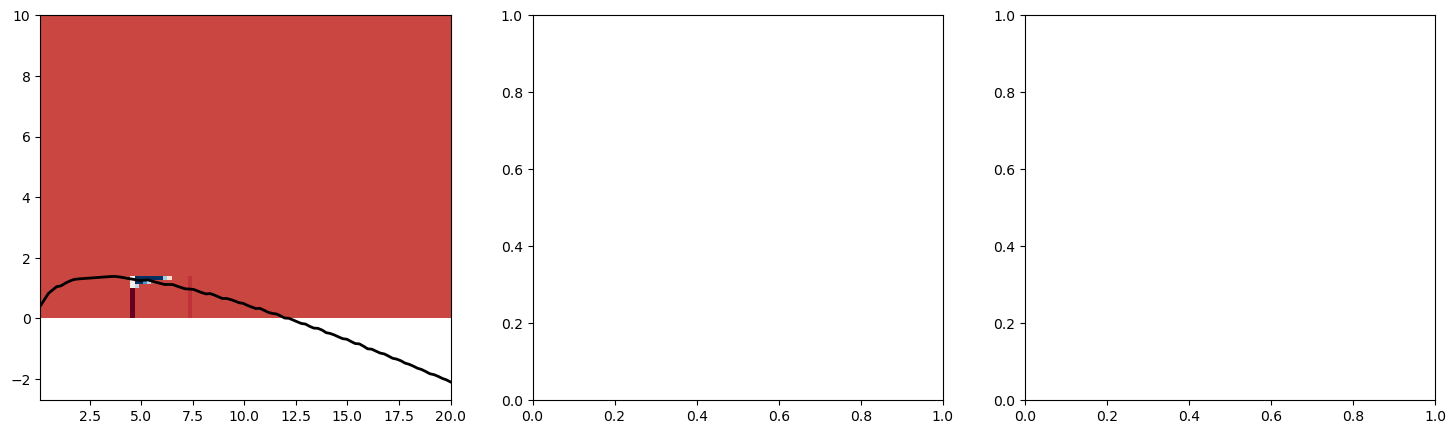

In [13]:
# %% ─── GP Posterior Heatmap ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Posterior mean Q̂(z=1, k, i)
ax = axes[0]
im0 = ax.imshow(gp.mu[0, :, :].T, origin='lower', aspect='auto',
                extent=[k_grid[0], k_grid[-1], i_grid[0], i_grid[-1]],
                cmap='RdBu_r')
ax.plot(k_grid, pol_rat, 'k-', lw=2, label='Rational $i^*(k)$')
gp_pol = np.array([gp_soft_policy(gp, 0, ik) for ik in range(len(k_grid))])
ax.plot(k_grid, gp_pol, 'lime', lw=2, ls='--', label='GP policy')
ax.set_xlabel('$k$'); ax.set_ylabel('$i$')
ax.set_title('Posterior Mean $\\hat{Q}(z, k, i)$')
ax.legend(loc='upper left', fontsize=8)
plt.colorbar(im0, ax=ax)

# Panel 2: Posterior std dev
ax = axes[1]
std_map = np.sqrt(gp.var[0, :, :])
im1 = ax.imshow(std_map.T, origin='lower', aspect='auto',
                extent=[k_grid[0], k_grid[-1], i_grid[0], i_grid[-1]],
                cmap='magma_r')
ax.plot(k_grid, pol_rat, 'cyan', lw=2, label='Rational $i^*(k)$')
ax.set_xlabel('$k$'); ax.set_ylabel('$i$')
ax.set_title('Posterior Std Dev $\\sigma(z, k, i)$')
ax.legend(loc='upper left', fontsize=8)
plt.colorbar(im1, ax=ax)

# Panel 3: True Q* for comparison
ax = axes[2]
im2 = ax.imshow(Q_true.T, origin='lower', aspect='auto',
                extent=[k_grid[0], k_grid[-1], i_grid[0], i_grid[-1]],
                cmap='RdBu_r',
                vmin=gp.mu[0].min(), vmax=gp.mu[0].max())  # same scale as panel 1
ax.plot(k_grid, pol_rat, 'k-', lw=2, label='Rational $i^*(k)$')
ax.set_xlabel('$k$'); ax.set_ylabel('$i$')
ax.set_title('True $Q^*(z, k, i)$')
ax.legend(loc='upper left', fontsize=8)
plt.colorbar(im2, ax=ax)

plt.suptitle('GP Belief Surface After Learning', fontsize=14)
plt.tight_layout()
plt.show()

# %% ─── Slices at 3 capital levels ───────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
k_slices = [k_ss * 0.5, k_ss, k_ss * 1.5]

for ax, k_val in zip(axes, k_slices):
    ik = int(np.argmin(np.abs(k_grid - k_val)))
    
    ax.plot(i_grid, Q_true[ik, :], 'k-', lw=2, label='True $Q^*$')
    ax.plot(i_grid, gp.mu[0, ik, :], 'b--', lw=2, label='GP posterior')
    
    std = np.sqrt(gp.var[0, ik, :])
    ax.fill_between(i_grid, gp.mu[0,ik,:]-std, gp.mu[0,ik,:]+std,
                    alpha=0.2, color='blue')
    
    ax.axvline(pol_rat[ik], color='r', ls=':', lw=2, label=f'$i^*={pol_rat[ik]:.2f}$')
    ax.set_xlabel('$i$')
    ax.set_title(f'$k = {k_grid[ik]:.1f}$')
    if ax == axes[0]: ax.set_ylabel('$Q(z,k,i)$')
    ax.legend(fontsize=7)

plt.suptitle('Q-Function Slices: True vs Learned', fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
k_ss = rat.fixed_point()
i_ss = p.DELTA * k_ss
d_ss = env.dividend(1.0, k_ss, i_ss)

# grids
z_grid = rat.z_grid
k_grid = rat.k_grid
i_grid = np.linspace(0.0, 3.5, 80)

# true Q*
ev_func = interp1d(k_grid, rat.v[0, :], kind='linear', fill_value='extrapolate')
Q_true = np.zeros((k_grid.size, i_grid.size))
for ik, k in enumerate(k_grid):
    for ii, iv in enumerate(i_grid):
        kp = (1 - p.DELTA) * k + iv
        kp_clip = np.clip(kp, k_grid[0], k_grid[-1])
        Q_true[ik, ii] = env.dividend(1.0, k, iv) + p.BETA * ev_func(kp_clip)

# rational i*(k)
pol_rat = np.array([rat.policy_kprime(1.0, k) - (1 - p.DELTA) * k for k in k_grid])

# GP — wider lengthscales + bigger bands
cfg = GPBeliefConfig(sigma0=2.0, lz=0.5, lk=5.0, li=2.0, band_z=1, band_k=10, band_i=10)
gp = GridGPBelief(z_grid, k_grid, i_grid, cfg)
gp.initialize_prior_mean(lambda z, k, i: env.dividend(z, k, i) + p.BETA / (1 - p.BETA) * d_ss)

# softmax policy readout
def gp_soft_policy(gp, iz, ik, temperature=0.5):
    q = gp.mu[iz, ik, :]
    weights = np.exp((q - q.max()) / temperature)
    weights /= weights.sum()
    return float(np.dot(weights, gp.i_grid))

# ─── simulate with exploration
np.random.seed(42)
T = 3000
epsilon = 0.15  # exploration rate
sigma_shock = 0.03

# multiple starting points for coverage
starts = [k_ss * 0.3, k_ss * 0.7, k_ss * 1.0, k_ss * 1.5, k_ss * 2.0]
hist = {key: [] for key in ['k', 'i_gp', 'i_rat', 'td', 'd']}

z_t = 1.0
k_t = starts[0]
restart_every = T // len(starts)

for t in range(T):
    # restart at different k levels for exploration
    if t > 0 and t % restart_every == 0:
        idx = t // restart_every
        if idx < len(starts):
            k_t = starts[idx]
            z_t = 1.0

    iz = gp.z_idx(z_t)
    ik = gp.k_idx(k_t)

    # ε-greedy: explore or exploit
    if np.random.random() < epsilon:
        ii_best = np.random.randint(0, len(i_grid))
    else:
        ii_best = gp.best_i_idx(iz, ik)
    i_gp = i_grid[ii_best]

    # rational benchmark
    i_rat = rat.policy_kprime(z_t, k_t) - (1 - p.DELTA) * k_t

    # step
    d_t = env.dividend(z_t, k_t, i_gp)
    k_next = np.clip((1 - p.DELTA) * k_t + i_gp, k_grid[0], k_grid[-1])
    z_next = np.exp(np.random.normal(0, sigma_shock))

    # outcome greedy
    iz_n = gp.z_idx(z_next)
    ik_n = gp.k_idx(k_next)
    ii_n = gp.best_i_idx(iz_n, ik_n)
    i_next = i_grid[ii_n]

    # TD error
    q_dec = gp.mu[iz, ik, ii_best]
    q_out = gp.mu[iz_n, ik_n, ii_n]
    td = d_t + p.BETA * q_out - q_dec

    # update
    gp.update_experience(
        beta=p.BETA,
        z_dec=z_t, k_dec=k_t, i_dec=i_gp,
        z_out=z_next, k_out=k_next, i_out=i_next,
        td_error=td,
    )

    hist['k'].append(k_t)
    hist['i_gp'].append(i_gp)
    hist['i_rat'].append(i_rat)
    hist['td'].append(td)
    hist['d'].append(d_t)

    z_t, k_t = z_next, k_next

hist = {k: np.array(v) for k, v in hist.items()}

# ─── sanity check
print(f"mu range:  [{gp.mu.min():.4f}, {gp.mu.max():.4f}]")
print(f"var range: [{gp.var.min():.6f}, {gp.var.max():.6f}]")
print(f"any NaN:   {np.any(np.isnan(gp.mu))}")

# ─── belief snapshot at k*
ik_ss = gp.k_idx(k_ss)
q_slice = gp.mu[0, ik_ss, :]
v_slice = gp.var[0, ik_ss, :]
ii_gp = gp.best_i_idx(0, ik_ss)
print(f"\n── Belief at k ≈ k* = {k_grid[ik_ss]:.2f} ──")
print(f"  GP best i = {i_grid[ii_gp]:.3f},  rational i* = {p.DELTA * k_ss:.3f}")
print(f"  GP soft i = {gp_soft_policy(gp, 0, ik_ss):.3f}")
print(f"  Q range:  [{q_slice.min():.2f}, {q_slice.max():.2f}]")
print(f"  Var range: [{v_slice.min():.4f}, {v_slice.max():.4f}]")

mu range:  [-714504188378551974081669094547909782593506565151608792775763860247281664.0000, 825961076089659901446012806652034627377045946054165200140107280132603904.0000]
var range: [0.001000, 4.000000]
any NaN:   False

── Belief at k ≈ k* = 9.95 ──
  GP best i = 1.063,  rational i* = 0.497
  GP soft i = 1.883
  Q range:  [-351637664474730479614951424.00, 351637664474730479614951424.00]
  Var range: [0.0010, 0.0010]


In [29]:

k_ss = rat.fixed_point()
i_ss = p.DELTA * k_ss
d_ss = env.dividend(1.0, k_ss, i_ss)

# grids
z_grid = rat.z_grid
k_grid = rat.k_grid
i_grid = np.linspace(0.0, 3.5, 80)

# true Q*
ev_func = interp1d(k_grid, rat.v[0, :], kind='linear', fill_value='extrapolate')

# GP
cfg = GPBeliefConfig(sigma0=2.0, lz=0.5, lk=2.0, li=0.8, band_z=1, band_k=6, band_i=6)
gp = GridGPBelief(z_grid, k_grid, i_grid, cfg)
gp.initialize_prior_mean(lambda z, k, i: env.dividend(z, k, i) + p.BETA / (1 - p.BETA) * d_ss)

# ─── header
print(f"{'t':>3} | {'z_t':>6} {'k_t':>7} {'i_gp':>6} {'i_rat':>6} | "
      f"{'d_t':>7} {'Q_dec':>7} {'Q_out':>7} {'TD':>8} | "
      f"{'var_dec':>8} {'var_out':>8} {'var_delta':>9} | "
      f"{'max_gain':>9} {'mean_|Δμ|':>9}")
print("-" * 130)

np.random.seed(42)
T = 20
z_t, k_t = 1.0, k_ss * 0.7

for t in range(T):
    iz = gp.z_idx(z_t)
    ik = gp.k_idx(k_t)

    # GP greedy
    ii_best = gp.best_i_idx(iz, ik)
    i_gp = i_grid[ii_best]

    # rational
    i_rat = rat.policy_kprime(z_t, k_t) - (1 - p.DELTA) * k_t

    # step
    d_t = env.dividend(z_t, k_t, i_gp)
    k_next = np.clip((1 - p.DELTA) * k_t + i_gp, k_grid[0], k_grid[-1])
    z_next = np.exp(np.random.normal(0, 0.03))

    # outcome greedy
    iz_n = gp.z_idx(z_next)
    ik_n = gp.k_idx(k_next)
    ii_n = gp.best_i_idx(iz_n, ik_n)
    i_next = i_grid[ii_n]

    # TD components
    q_dec = gp.mu[iz, ik, ii_best]
    q_out = gp.mu[iz_n, ik_n, ii_n]
    td = d_t + p.BETA * q_out - q_dec

    # variances at anchor points (before update)
    v_dec = gp.var[iz, ik, ii_best]
    v_out = gp.var[iz_n, ik_n, ii_n]
    k_cross = gp._kernel_scalar(
        gp.z_grid[iz], gp.k_grid[ik], i_grid[ii_best],
        gp.z_grid[iz_n], gp.k_grid[ik_n], i_grid[ii_n])
    var_delta = v_dec + p.BETA**2 * v_out - 2 * p.BETA * k_cross

    # snapshot before update
    mu_before = gp.mu.copy()

    # update
    gp.update_experience(
        beta=p.BETA,
        z_dec=z_t, k_dec=k_t, i_dec=i_gp,
        z_out=z_next, k_out=k_next, i_out=i_next,
        td_error=td,
    )

    # measure update magnitude
    delta_mu = np.abs(gp.mu - mu_before)
    max_gain = np.max(delta_mu)
    mean_gain = np.mean(delta_mu[delta_mu > 1e-12])

    print(f"{t:3d} | {z_t:6.3f} {k_t:7.3f} {i_gp:6.3f} {i_rat:6.3f} | "
          f"{d_t:7.3f} {q_dec:7.2f} {q_out:7.2f} {td:8.4f} | "
          f"{v_dec:8.4f} {v_out:8.4f} {var_delta:9.4f} | "
          f"{max_gain:9.5f} {mean_gain:9.5f}")

    z_t, k_t = z_next, k_next

# ─── post-learning snapshot at steady state
print("\n── Belief snapshot at k ≈ k* ──")
ik_ss = gp.k_idx(k_ss)
q_slice = gp.mu[0, ik_ss, :]
v_slice = gp.var[0, ik_ss, :]
ii_gp = gp.best_i_idx(0, ik_ss)

print(f"  k = {k_grid[ik_ss]:.3f}")
print(f"  GP best i = {i_grid[ii_gp]:.3f},  rational i* = {p.DELTA * k_ss:.3f}")
print(f"  Q at GP best:  μ = {q_slice[ii_gp]:.4f},  σ = {np.sqrt(v_slice[ii_gp]):.4f}")
print(f"  Q range:  [{q_slice.min():.2f}, {q_slice.max():.2f}]")
print(f"  Var range: [{v_slice.min():.4f}, {v_slice.max():.4f}]  (prior was {cfg.sigma0**2:.2f})")

  t |    z_t     k_t   i_gp  i_rat |     d_t   Q_dec   Q_out       TD |  var_dec  var_out var_delta |  max_gain mean_|Δμ|
----------------------------------------------------------------------------------------------------------------------------------
  0 |  1.000   6.965  0.000  1.013 |   1.897   83.43   83.39   0.2253 |   4.0000   4.0000    0.1584 |   0.70618   0.36835
  1 |  1.015   6.616  0.000  1.095 |   1.894   83.39   83.26   0.1310 |   4.0000   3.9600    0.0026 |  13.65046   6.61270
  2 |  0.996   6.286  0.000  1.121 |   1.827   86.17   83.02  -2.9539 |   2.6645   4.0000   -0.6207 | 25423255783.76987 10406851121.17500
  3 |  1.020   5.971  0.576  1.149 |   1.249 20259573420.71 16243681332.21 -4334395642.7831 |   0.0000   0.0000   -7.6863 | 21523130282729222144.00000 11209568640252207104.00000
  4 |  1.047   6.249  0.576  1.120 |   1.327 67960468563152808.00 3448635932876762112.00 3313055151904260608.0000 |   0.0000   0.0000   -7.8036 | 9050359046276008957047734272.00000 437753

In [7]:
# %% ─── Sanity check: did it blow up? ────────────────────────────
print(f"mu range:  [{gp.mu.min():.4f}, {gp.mu.max():.4f}]")
print(f"var range: [{gp.var.min():.6f}, {gp.var.max():.6f}]")
print(f"any NaN:   mu={np.any(np.isnan(gp.mu))}, var={np.any(np.isnan(gp.var))}")
print(f"any Inf:   mu={np.any(np.isinf(gp.mu))}, var={np.any(np.isinf(gp.var))}")

# if blown up, find where
if np.abs(gp.mu).max() > 1e6:
    print("\n⚠️  BLOWUP DETECTED — beliefs diverged")
    worst = np.unravel_index(np.argmax(np.abs(gp.mu)), gp.mu.shape)
    print(f"  worst point: iz={worst[0]}, ik={worst[1]}, ii={worst[2]}")
    print(f"  mu = {gp.mu[worst]:.4e}, var = {gp.var[worst]:.4e}")

mu range:  [nan, nan]
var range: [0.000000, 4.000000]
any NaN:   mu=True, var=False
any Inf:   mu=True, var=False


n=   0 | k= 7.55 i=3.33 | Q*_dec=  57.13 Q̂_dec=  56.71 | td=  0.4655 | mu_range=[55.05, 60.77]
n=   1 | k= 3.20 i=0.20 | Q*_dec=  52.30 Q̂_dec=  59.32 | td= -6.9980 | mu_range=[55.05, 60.77]
n=   2 | k=12.06 i=2.48 | Q*_dec=  61.76 Q̂_dec=  57.89 | td=  3.8058 | mu_range=[55.05, 60.77]
n=   3 | k= 3.75 i=1.06 | Q*_dec=  52.98 Q̂_dec=  56.79 | td= -3.8217 | mu_range=[51.99, 63.09]
n=   4 | k= 8.70 i=1.02 | Q*_dec=  58.32 Q̂_dec=  58.98 | td= -0.7154 | mu_range=[51.99, 63.09]
n=   5 | k= 7.39 i=1.60 | Q*_dec=  56.96 Q̂_dec=  58.42 | td= -1.4447 | mu_range=[51.99, 63.09]
n=   6 | k= 4.07 i=1.80 | Q*_dec=  53.37 Q̂_dec=  59.94 | td= -6.6131 | mu_range=[46.65, 67.81]
n=   7 | k= 3.49 i=0.23 | Q*_dec=  52.64 Q̂_dec=  55.73 | td= -3.1181 | mu_range=[45.60, 67.81]
n=   8 | k=19.32 i=2.83 | Q*_dec=  67.61 Q̂_dec=  57.91 | td=  7.9692 | mu_range=[45.60, 67.81]
n=   9 | k= 8.86 i=0.43 | Q*_dec=  58.49 Q̂_dec=  59.50 | td= -1.0270 | mu_range=[45.60, 67.81]
n= 500 | k=12.73 i=0.58 | Q*_dec=  62.46

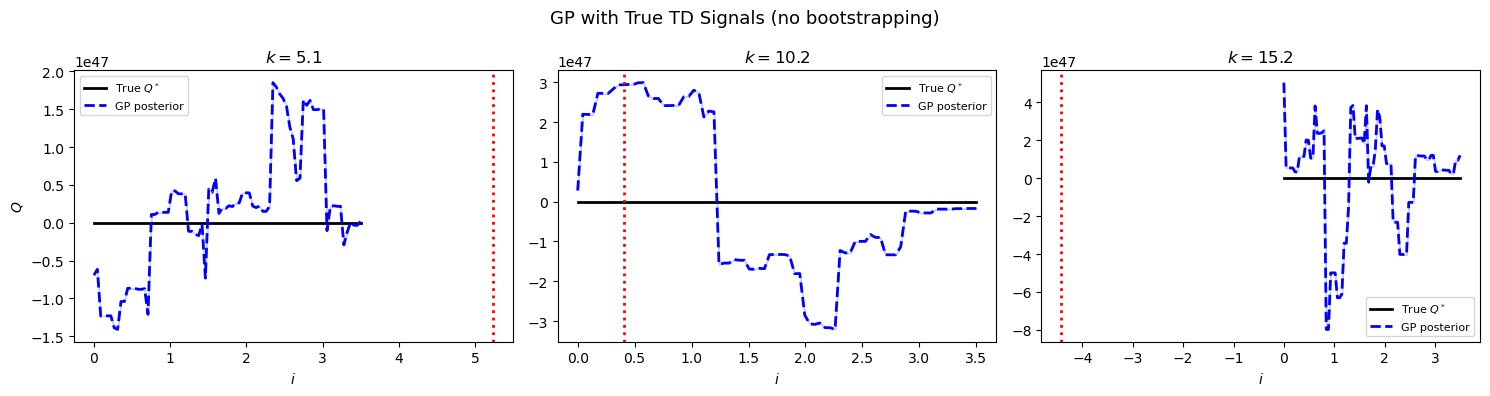

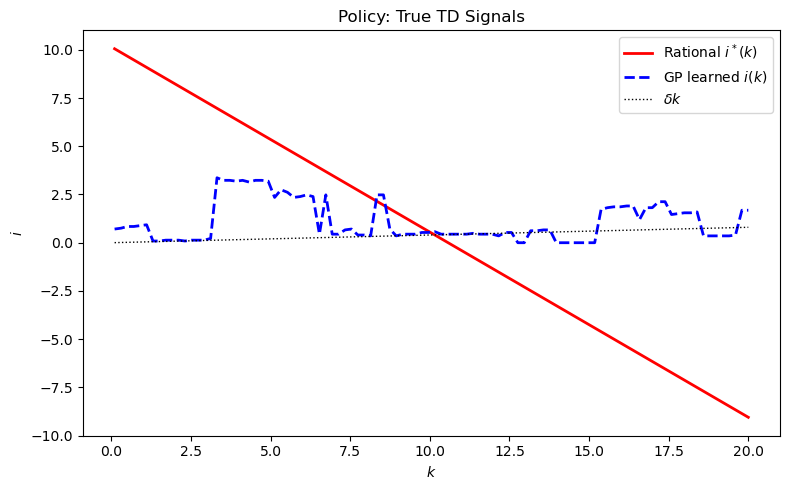

In [23]:
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt

p = InvestmentParameters(KAPPA=0.0, SIGMA_EPS=0.0)
env = InvestmentEnvironment(p)
rat = RationalInvestment(p).fit()

k_ss = rat.fixed_point()
d_ss = env.dividend(1.0, k_ss, p.DELTA * k_ss)

z_grid = rat.z_grid
k_grid = rat.k_grid
i_grid = np.linspace(0.0, 3.5, 80)

# true Q* and V*
ev_func = interp1d(k_grid, rat.v[0, :], kind='linear', fill_value='extrapolate')

def Q_star(z, k, i):
    kp = np.clip((1 - p.DELTA) * k + i, k_grid[0], k_grid[-1])
    return env.dividend(z, k, i) + p.BETA * ev_func(kp)

Q_true = np.zeros((k_grid.size, i_grid.size))
for ik, k in enumerate(k_grid):
    for ii, iv in enumerate(i_grid):
        Q_true[ik, ii] = Q_star(1.0, k, iv)

pol_rat = np.array([rat.policy_kprime(1.0, k) - (1 - p.DELTA) * k for k in k_grid])

# GP
cfg = GPBeliefConfig(sigma0=2.0, lz=0.5, lk=5.0, li=2.0, band_z=1, band_k=10, band_i=10)
gp = GridGPBelief(z_grid, k_grid, i_grid, cfg)
gp.initialize_prior_mean(lambda z, k, i: env.dividend(z, k, i) + p.BETA / (1 - p.BETA) * d_ss)

# %% ─── Feed TRUE TD errors from random (k, i) pairs ─────────────
# No bootstrapping: TD uses true Q*, not GP beliefs
# δ = d(z, k, i) + β * V*(z', k') − Q*(z, k, i)
#   = 0 when using true values (by Bellman), plus small shock noise

np.random.seed(42)
N_obs = 3000
sigma_shock = 0.03

for n in range(N_obs):
    # random state and action
    k = np.random.uniform(k_grid[0], k_grid[-1])
    i = np.random.uniform(i_grid[0], i_grid[-1])
    z = 1.0

    # transition
    k_next = np.clip((1 - p.DELTA) * k + i, k_grid[0], k_grid[-1])
    eps = np.random.normal(0, sigma_shock)
    z_next = np.exp(eps)

    # random action at outcome (NOT max — just random)
    i_next = np.random.uniform(i_grid[0], i_grid[-1])

    # TRUE TD error: use actual Q* at both points
    q_dec_true = Q_star(z, k, i)
    q_out_true = Q_star(z_next, k_next, i_next)
    td_true = env.dividend(z, k, i) + p.BETA * q_out_true - q_dec_true

    # but the GP computes its own TD internally — so we feed:
    # td_error = d + β Q̂_out − Q̂_dec  (what the GP sees)
    # instead, override: tell the GP the TRUE residual relative to its own beliefs
    iz = gp.z_idx(z); ik = gp.k_idx(k); ii = gp.i_idx(i)
    iz_n = gp.z_idx(z_next); ik_n = gp.k_idx(k_next); ii_n = gp.i_idx(i_next)

    q_dec_gp = gp.mu[iz, ik, ii]
    q_out_gp = gp.mu[iz_n, ik_n, ii_n]
    td_gp = env.dividend(z, k, i) + p.BETA * q_out_true - q_dec_gp
    # ↑ uses true Q* at outcome, GP belief at decision
    # this is the "target network" idea: outcome is grounded in truth

    gp.update_experience(
        beta=p.BETA,
        z_dec=z, k_dec=k, i_dec=i,
        z_out=z_next, k_out=k_next, i_out=i_next,
        td_error=td_gp,
    )

    if n < 10 or n % 500 == 0:
        print(f"n={n:4d} | k={k:5.2f} i={i:4.2f} | "
              f"Q*_dec={q_dec_true:7.2f} Q̂_dec={q_dec_gp:7.2f} | "
              f"td={td_gp:8.4f} | mu_range=[{gp.mu.min():.2f}, {gp.mu.max():.2f}]")

# %% ─── Diagnostics ──────────────────────────────────────────────
print(f"\nmu range:  [{gp.mu.min():.4f}, {gp.mu.max():.4f}]")
print(f"var range: [{gp.var.min():.6f}, {gp.var.max():.6f}]")
print(f"any NaN:   {np.any(np.isnan(gp.mu))}")

# %% ─── Plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, k_val in enumerate([k_ss * 0.5, k_ss, k_ss * 1.5]):
    ax = axes[idx]
    ik = int(np.argmin(np.abs(k_grid - k_val)))
    ax.plot(i_grid, Q_true[ik, :], 'k-', lw=2, label='True $Q^*$')
    ax.plot(i_grid, gp.mu[0, ik, :], 'b--', lw=2, label='GP posterior')
    std = np.sqrt(gp.var[0, ik, :])
    ax.fill_between(i_grid, gp.mu[0,ik,:]-std, gp.mu[0,ik,:]+std, alpha=0.2, color='blue')
    ax.axvline(pol_rat[ik], color='r', ls=':', lw=2)
    ax.set_xlabel('$i$'); ax.set_title(f'$k = {k_grid[ik]:.1f}$')
    if idx == 0: ax.set_ylabel('$Q$')
    ax.legend(fontsize=8)
plt.suptitle('GP with True TD Signals (no bootstrapping)', fontsize=13)
plt.tight_layout(); plt.show()

# policy
fig, ax = plt.subplots(figsize=(8, 5))
gp_pol = np.array([i_grid[gp.best_i_idx(0, ik)] for ik in range(len(k_grid))])
ax.plot(k_grid, pol_rat, 'r-', lw=2, label='Rational $i^*(k)$')
ax.plot(k_grid, gp_pol, 'b--', lw=2, label='GP learned $i(k)$')
ax.plot(k_grid, p.DELTA * k_grid, 'k:', lw=1, label='$\\delta k$')
ax.set_xlabel('$k$'); ax.set_ylabel('$i$')
ax.set_title('Policy: True TD Signals'); ax.legend()
plt.tight_layout(); plt.show()

n=   0 | k= 7.55 i=3.33 | Q*=  57.13 Q̂=  56.71 innov=  0.749 | mu_range=[55.05, 60.77]
n=   1 | k= 3.20 i=0.55 | Q*=  52.32 Q̂=  59.01 innov= -5.924 | mu_range=[53.06, 60.77]
n=   2 | k= 1.26 i=3.03 | Q*=  50.10 Q̂=  56.16 innov= -5.277 | mu_range=[50.39, 60.77]
n=   3 | k= 0.51 i=3.39 | Q*=  49.08 Q̂=  50.66 innov= -1.196 | mu_range=[43.80, 60.77]
n=   4 | k=16.67 i=0.74 | Q*=  66.39 Q̂=  59.86 innov=  6.301 | mu_range=[43.80, 66.09]
n= 500 | k= 0.82 i=1.06 | Q*=  49.32 Q̂=-332910798895750691489316864.00 innov=332910798895750691489316864.000 | mu_range=[-359857439595818317965056698789447180746752.00, 43721869725498793538788559525724624519168.00]
n=1000 | k=16.88 i=1.70 | Q*=  66.58 Q̂=4581391678009873468177084364511250314027641549534843550600522715734994845696.00 innov=-4581391678009873468177084364511250314027641549534843550600522715734994845696.000 | mu_range=[-597906398569816829554557193024390204804614919316631774206842847888654391504169993240576.00, 1165098744037444367674057605753

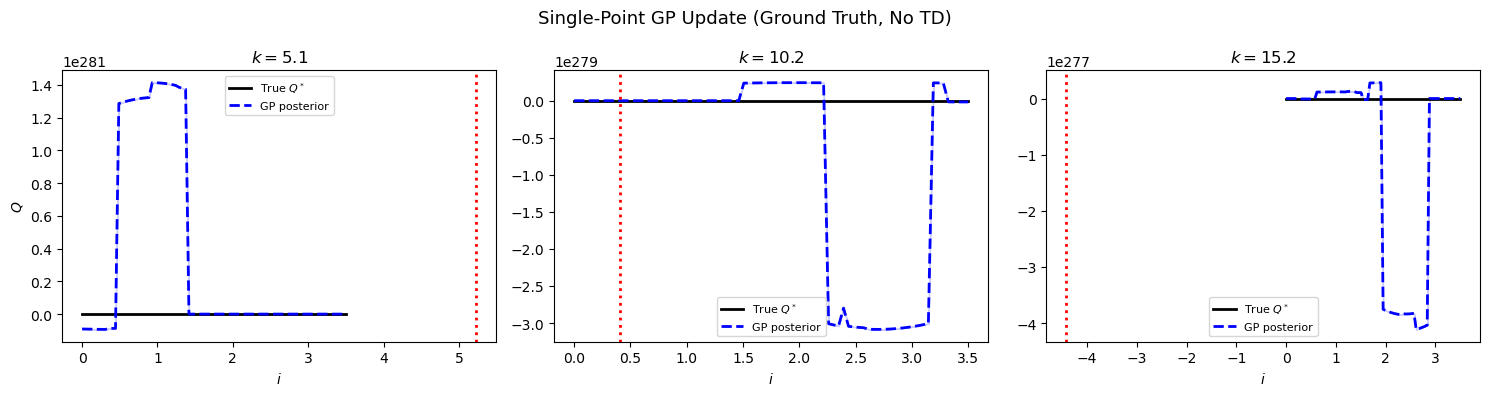

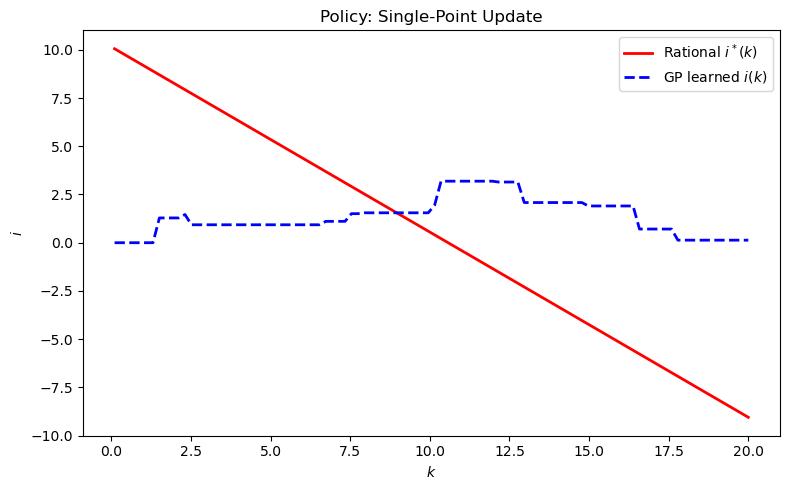

In [24]:
env = InvestmentEnvironment(p)
rat = RationalInvestment(p).fit()
k_ss = rat.fixed_point()
d_ss = env.dividend(1.0, k_ss, p.DELTA * k_ss)

z_grid = rat.z_grid
k_grid = rat.k_grid
i_grid = np.linspace(0.0, 3.5, 80)

ev_func = interp1d(k_grid, rat.v[0, :], kind='linear', fill_value='extrapolate')
def Q_star(z, k, i):
    kp = np.clip((1 - p.DELTA) * k + i, k_grid[0], k_grid[-1])
    return env.dividend(z, k, i) + p.BETA * ev_func(kp)

Q_true = np.zeros((k_grid.size, i_grid.size))
for ik, k in enumerate(k_grid):
    for ii, iv in enumerate(i_grid):
        Q_true[ik, ii] = Q_star(1.0, k, iv)
pol_rat = np.array([rat.policy_kprime(1.0, k) - (1 - p.DELTA) * k for k in k_grid])

# GP
cfg = GPBeliefConfig(sigma0=2.0, lz=0.5, lk=5.0, li=2.0, band_z=1, band_k=10, band_i=10)
gp = GridGPBelief(z_grid, k_grid, i_grid, cfg)
gp.initialize_prior_mean(lambda z, k, i: env.dividend(z, k, i) + p.BETA / (1 - p.BETA) * d_ss)

# %% ─── Simple single-point update (bypass update_experience) ────
# For each observation: y = Q*(z,k,i) + noise
# Innovation: y - μ̂(z,k,i)
# Gain: k(obs, x) / (var(obs) + σ²_noise)

np.random.seed(42)
N_obs = 3000
sigma_noise = 0.5

for n in range(N_obs):
    z = 1.0
    k = np.random.uniform(k_grid[0], k_grid[-1])
    i = np.random.uniform(i_grid[0], i_grid[-1])

    y = Q_star(z, k, i) + np.random.normal(0, sigma_noise)

    # manual single-point GP update
    iz = gp.z_idx(z); ik = gp.k_idx(k); ii = gp.i_idx(i)
    z0 = gp.z_grid[iz]; k0 = gp.k_grid[ik]; i0 = gp.i_grid[ii]

    mu_obs = gp.mu[iz, ik, ii]
    v_obs = gp.var[iz, ik, ii]
    innovation = y - mu_obs

    obs_var = v_obs + sigma_noise**2
    obs_var = max(obs_var, cfg.var_floor)

    # band
    bz, bk, bi = cfg.band_z, cfg.band_k, cfg.band_i
    iz_lo = max(0, iz - bz); iz_hi = min(gp.Nz, iz + bz + 1)
    ik_lo = max(0, ik - bk); ik_hi = min(gp.Nk, ik + bk + 1)
    ii_lo = max(0, ii - bi); ii_hi = min(gp.Ni, ii + bi + 1)

    cov_block = gp._kernel_to_band(z0, k0, i0,
                                    iz_lo, iz_hi, ik_lo, ik_hi, ii_lo, ii_hi)
    gain = cov_block / obs_var

    sl = np.s_[iz_lo:iz_hi, ik_lo:ik_hi, ii_lo:ii_hi]
    gp.mu[sl] += gain * innovation
    gp.var[sl] = np.maximum(gp.var[sl] - gain * cov_block, cfg.var_floor)

    if n < 5 or n % 500 == 0:
        print(f"n={n:4d} | k={k:5.2f} i={i:4.2f} | "
              f"Q*={Q_star(z,k,i):7.2f} Q̂={mu_obs:7.2f} innov={innovation:7.3f} | "
              f"mu_range=[{gp.mu.min():.2f}, {gp.mu.max():.2f}]")

# %% ─── Diagnostics ──────────────────────────────────────────────
print(f"\nmu range:  [{gp.mu.min():.4f}, {gp.mu.max():.4f}]")
print(f"var range: [{gp.var.min():.6f}, {gp.var.max():.6f}]")
print(f"any NaN:   {np.any(np.isnan(gp.mu))}")

# %% ─── Plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, k_val in enumerate([k_ss * 0.5, k_ss, k_ss * 1.5]):
    ax = axes[idx]
    ik = int(np.argmin(np.abs(k_grid - k_val)))
    ax.plot(i_grid, Q_true[ik, :], 'k-', lw=2, label='True $Q^*$')
    ax.plot(i_grid, gp.mu[0, ik, :], 'b--', lw=2, label='GP posterior')
    std = np.sqrt(gp.var[0, ik, :])
    ax.fill_between(i_grid, gp.mu[0,ik,:]-std, gp.mu[0,ik,:]+std, alpha=0.2, color='blue')
    ax.axvline(pol_rat[ik], color='r', ls=':', lw=2)
    ax.set_xlabel('$i$'); ax.set_title(f'$k = {k_grid[ik]:.1f}$')
    if idx == 0: ax.set_ylabel('$Q$')
    ax.legend(fontsize=8)
plt.suptitle('Single-Point GP Update (Ground Truth, No TD)', fontsize=13)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
gp_pol = np.array([i_grid[gp.best_i_idx(0, ik)] for ik in range(len(k_grid))])
ax.plot(k_grid, pol_rat, 'r-', lw=2, label='Rational $i^*(k)$')
ax.plot(k_grid, gp_pol, 'b--', lw=2, label='GP learned $i(k)$')
ax.set_xlabel('$k$'); ax.set_ylabel('$i$')
ax.set_title('Policy: Single-Point Update'); ax.legend()
plt.tight_layout(); plt.show()

In [25]:
"""
ExactGPBelief — Exact GP inference with two-point TD observations.

Each TD observation constrains a LINEAR COMBINATION of Q* at two points:

    y_t = Q*(x_dec) − β Q*(x_out) + ε_t

where y_t = d(z, k, i) is the observed dividend and ε_t ~ N(0, σ²_obs).

This is the correct observation model from the paper's Bellman rearrangement:
    u(c, s) = Q*(s, c) − β E[Q*(s', c')]  →  single-sample approximation

The GP maintains a list of observations and does exact inference.
No diagonal approximation — covariance consistency is automatic.

Cost: O(N³) per fit, O(N²M) per prediction with M query points.
For N ≤ 3000 this is seconds, not minutes.
"""

from __future__ import annotations
from dataclasses import dataclass
import numpy as np


@dataclass
class ExactGPConfig:
    # RBF kernel
    sigma0: float = 2.0
    lz: float = 0.5
    lk: float = 5.0
    li: float = 2.0

    # observation noise std (TD signal noise)
    sigma_obs: float = 0.5

    # max observations to store (oldest get dropped)
    max_obs: int = 2000


class ExactGPBelief:
    def __init__(self, cfg: ExactGPConfig, prior_mean_func, beta: float):
        """
        Args:
            cfg: kernel and noise config
            prior_mean_func: callable(z, k, i) -> float, prior mean of Q*
            beta: discount factor
        """
        self.cfg = cfg
        self.prior_mean = prior_mean_func
        self.beta = beta

        # stored observations — each row is (z, k, i)
        self._X_dec = []  # decision points
        self._X_out = []  # outcome points
        self._y = []      # observed dividends

        # cached after fit()
        self._L = None       # Cholesky factor
        self._alpha = None   # (K + σ²I)^{-1} (y - m)
        self._dirty = True

        # numpy versions built at fit time
        self._Xd = None  # (N, 3)
        self._Xo = None  # (N, 3)

    @property
    def n_obs(self) -> int:
        return len(self._y)

    # ── kernel (vectorized) ───────────────────────────────────────
    def _kernel_mat(self, X1: np.ndarray, X2: np.ndarray) -> np.ndarray:
        """
        RBF kernel between (N1, 3) and (N2, 3) arrays.
        Returns (N1, N2) matrix.
        """
        cfg = self.cfg
        scales = np.array([cfg.lz, cfg.lk, cfg.li])
        X1s = X1 / scales  # (N1, 3)
        X2s = X2 / scales  # (N2, 3)
        # ||x1 - x2||² = ||x1||² + ||x2||² - 2 x1·x2
        sq_dist = (
            np.sum(X1s ** 2, axis=1, keepdims=True)
            + np.sum(X2s ** 2, axis=1, keepdims=True).T
            - 2.0 * X1s @ X2s.T
        )
        return cfg.sigma0 ** 2 * np.exp(-0.5 * sq_dist)

    # ── add observations ──────────────────────────────────────────
    def add_td_observation(self,
                           z_dec: float, k_dec: float, i_dec: float,
                           z_out: float, k_out: float, i_out: float,
                           dividend: float):
        """
        Add a TD observation.

        The constraint is: Q*(x_dec) − β Q*(x_out) ≈ dividend

        Args:
            z_dec, k_dec, i_dec: decision point (z, k, i) at t-1
            z_out, k_out, i_out: outcome point (z', k', ĩ) at t
            dividend: d(z, k, i) observed at t-1
        """
        self._X_dec.append(np.array([z_dec, k_dec, i_dec]))
        self._X_out.append(np.array([z_out, k_out, i_out]))
        self._y.append(dividend)
        self._dirty = True

        # drop oldest if over limit
        if len(self._y) > self.cfg.max_obs:
            self._X_dec.pop(0)
            self._X_out.pop(0)
            self._y.pop(0)

    def add_direct_observation(self, z: float, k: float, i: float, q_value: float):
        """
        Add a direct observation: Q*(z, k, i) ≈ q_value.

        Implemented as a TD obs with β=0 trick:
        set x_out = x_dec, dividend = q_value, then:
            Q*(x_dec) - β Q*(x_dec) = (1-β) Q*(x_dec)
        
        Actually simpler: store x_out far away so kernel → 0.
        Cleanest: separate storage. But for simplicity, we use x_out = x_dec
        and handle it in the gram matrix.
        
        Actually, just store as TD with x_out = (0, 0, 0) at huge distance.
        kernel(x_dec, far_away) ≈ 0, so it reduces to a direct observation.
        """
        self._X_dec.append(np.array([z, k, i]))
        self._X_out.append(np.array([1e6, 1e6, 1e6]))  # far away → kernel ≈ 0
        self._y.append(q_value)
        self._dirty = True

        if len(self._y) > self.cfg.max_obs:
            self._X_dec.pop(0)
            self._X_out.pop(0)
            self._y.pop(0)

    # ── build gram matrix and solve ───────────────────────────────
    def fit(self):
        """
        Compute Cholesky factorization for prediction.

        Gram matrix for TD observations:
            G_{ij} = k(d_i, d_j) − β k(d_i, o_j) − β k(o_i, d_j) + β² k(o_i, o_j)

        where d_i = X_dec[i], o_i = X_out[i].
        """
        N = self.n_obs
        if N == 0:
            self._dirty = False
            return

        self._Xd = np.array(self._X_dec)  # (N, 3)
        self._Xo = np.array(self._X_out)  # (N, 3)

        beta = self.beta

        # four kernel sub-matrices
        K_dd = self._kernel_mat(self._Xd, self._Xd)  # (N, N)
        K_do = self._kernel_mat(self._Xd, self._Xo)
        K_od = self._kernel_mat(self._Xo, self._Xd)
        K_oo = self._kernel_mat(self._Xo, self._Xo)

        # gram matrix for linear observations
        G = K_dd - beta * K_do - beta * K_od + beta ** 2 * K_oo
        G += self.cfg.sigma_obs ** 2 * np.eye(N)

        # prior means of observations: μ₀(x_dec) − β μ₀(x_out)
        m_dec = np.array([self.prior_mean(*x) for x in self._Xd])
        m_out = np.array([self.prior_mean(*x) for x in self._Xo])
        m = m_dec - beta * m_out

        # residuals
        y = np.array(self._y)
        residual = y - m

        # Cholesky solve
        self._L = np.linalg.cholesky(G)
        self._alpha = np.linalg.solve(
            self._L.T, np.linalg.solve(self._L, residual)
        )
        self._dirty = False

    # ── predict ───────────────────────────────────────────────────
    def predict(self, X_query: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """
        Posterior mean and variance at query points.

        Args:
            X_query: (M, 3) array of (z, k, i) points

        Returns:
            mu: (M,) posterior mean
            var: (M,) posterior marginal variance
        """
        if self._dirty:
            self.fit()

        M = X_query.shape[0]
        mu_prior = np.array([self.prior_mean(*x) for x in X_query])

        if self.n_obs == 0:
            return mu_prior, np.full(M, self.cfg.sigma0 ** 2)

        beta = self.beta

        # cross-covariance: Cov(obs_i, Q*(x_j)) = k(d_i, x_j) − β k(o_i, x_j)
        # shape: (N, M)
        K_dq = self._kernel_mat(self._Xd, X_query)  # (N, M)
        K_oq = self._kernel_mat(self._Xo, X_query)  # (N, M)
        K_star = K_dq - beta * K_oq                  # (N, M)

        # posterior mean
        mu = mu_prior + K_star.T @ self._alpha  # (M,)

        # posterior variance
        v = np.linalg.solve(self._L, K_star)  # (N, M)
        var_prior = self.cfg.sigma0 ** 2
        var = var_prior - np.sum(v ** 2, axis=0)  # (M,)
        var = np.maximum(var, 1e-8)

        return mu, var

    # ── convenience: query along action dimension ─────────────────
    def predict_q_slice(self, z: float, k: float, i_grid: np.ndarray
                        ) -> tuple[np.ndarray, np.ndarray]:
        """
        Posterior mean and var of Q*(z, k, ·) for all i in i_grid.

        Returns:
            mu: (Ni,) posterior means
            var: (Ni,) posterior variances
        """
        Ni = i_grid.size
        X_query = np.column_stack([
            np.full(Ni, z),
            np.full(Ni, k),
            i_grid,
        ])
        return self.predict(X_query)

    def best_action(self, z: float, k: float, i_grid: np.ndarray
                    ) -> tuple[float, float]:
        """
        Greedy action: argmax_i μ(z, k, i).

        Returns:
            (best_i, best_q)
        """
        mu, _ = self.predict_q_slice(z, k, i_grid)
        idx = np.argmax(mu)
        return float(i_grid[idx]), float(mu[idx])

    def soft_action(self, z: float, k: float, i_grid: np.ndarray,
                    temperature: float = 0.5) -> float:
        """
        Softmax-weighted action (smoother than argmax).
        """
        mu, _ = self.predict_q_slice(z, k, i_grid)
        w = np.exp((mu - mu.max()) / temperature)
        w /= w.sum()
        return float(np.dot(w, i_grid))

    # ── bulk grid prediction ──────────────────────────────────────
    def predict_grid(self, z_grid: np.ndarray, k_grid: np.ndarray,
                     i_grid: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """
        Predict on full (z, k, i) grid.

        Returns:
            mu: (Nz, Nk, Ni)
            var: (Nz, Nk, Ni)
        """
        Nz, Nk, Ni = z_grid.size, k_grid.size, i_grid.size

        # build (Nz*Nk*Ni, 3) query array
        zz, kk, ii = np.meshgrid(z_grid, k_grid, i_grid, indexing='ij')
        X_query = np.column_stack([zz.ravel(), kk.ravel(), ii.ravel()])

        mu_flat, var_flat = self.predict(X_query)

        return mu_flat.reshape(Nz, Nk, Ni), var_flat.reshape(Nz, Nk, Ni)

n=   0 | k= 7.55 i=9.51 | Q*=  78.25 obs=  80.19
n=   1 | k= 3.20 i=1.56 | Q*=  75.57 obs=  80.14
n=   2 | k= 1.26 i=8.66 | Q*=  61.97 obs=  66.71
n=   3 | k= 0.51 i=9.70 | Q*=  36.02 obs=  38.32
n=   4 | k=16.67 i=2.12 | Q*=  89.76 obs=  88.37
n= 200 | k= 4.99 i=1.61 | Q*=  77.79 obs=  76.01
n= 400 | k=10.58 i=7.32 | Q*=  82.70 obs=  80.74
n= 600 | k= 2.76 i=0.81 | Q*=  74.91 obs=  74.83
n= 800 | k= 7.61 i=9.64 | Q*=  78.25 obs=  79.04

Stored 1000 observations. Fitting...
Done.

At k* = 9.95:
  GP best i  = 9.076
  Rational i = 0.497
  mu range:  [10892751.89, 11144040.58]
  var range: [0.4670, 0.4803]


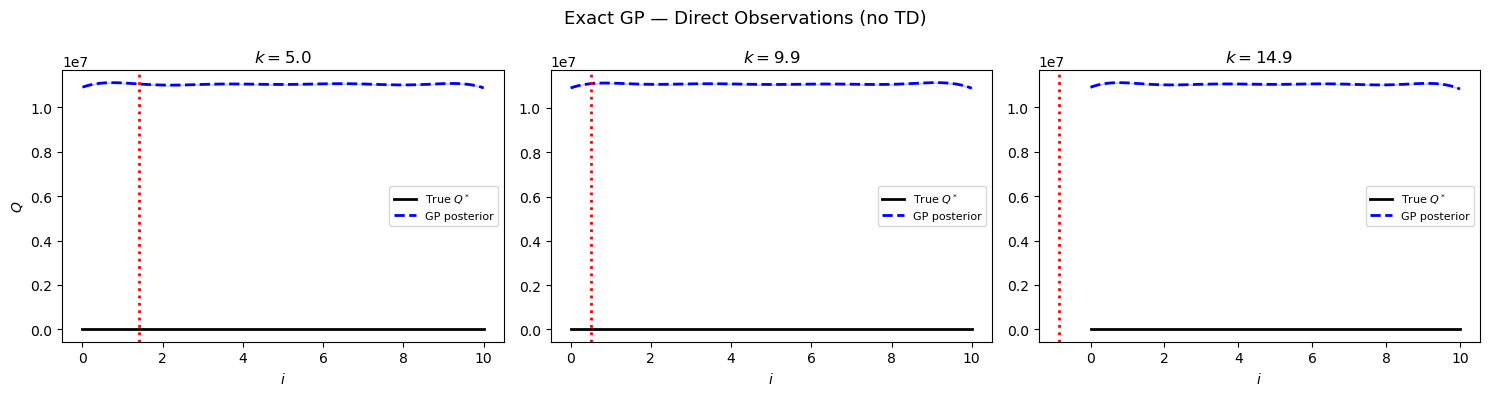

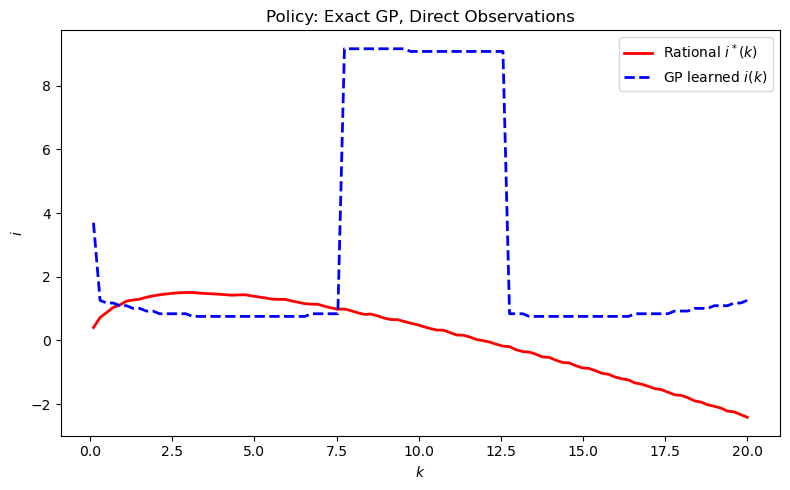

In [30]:

p = InvestmentParameters(KAPPA=0.4, SIGMA_EPS=0.0, DELTA=0.05, R=0.02)
env = InvestmentEnvironment(p)
rat = RationalInvestment(p).fit()
k_ss = rat.fixed_point()
d_ss = env.dividend(1.0, k_ss, p.DELTA * k_ss)

z_grid = rat.z_grid
k_grid = rat.k_grid
i_grid = np.linspace(0.0, 10, 120)

ev_func = interp1d(k_grid, rat.v[0, :], kind='linear', fill_value='extrapolate')
def Q_star(z, k, i):
    kp = np.clip((1 - p.DELTA) * k + i, k_grid[0], k_grid[-1])
    return env.dividend(z, k, i) + p.BETA * ev_func(kp)

Q_true = np.zeros((k_grid.size, i_grid.size))
for ik, k in enumerate(k_grid):
    for ii, iv in enumerate(i_grid):
        Q_true[ik, ii] = Q_star(1.0, k, iv)
pol_rat = np.array([rat.policy_kprime(1.0, k) - (1 - p.DELTA) * k for k in k_grid])

# prior mean
# def q_prior(z, k, i):
#     return env.dividend(z, k, i) + p.BETA / (1 - p.BETA) * d_ss

# %% ─── Direct observations test (no TD) ─────────────────────────

cfg = ExactGPConfig(sigma0=2.0, lz=0.5, lk=5.0, li=2.0, sigma_obs=0.5, max_obs=1500)
gp = ExactGPBelief(cfg, q_prior, beta=p.BETA)

np.random.seed(42)
N_obs = 1000

for n in range(N_obs):
    z = 1.0
    k = np.random.uniform(k_grid[0], k_grid[-1])
    i = np.random.uniform(i_grid[0], i_grid[-1])
    y = Q_star(z, k, i) + np.random.normal(0, 3)

    gp.add_direct_observation(z, k, i, y)

    if n < 5 or n % 200 == 0:
        print(f"n={n:4d} | k={k:5.2f} i={i:4.2f} | Q*={Q_star(z,k,i):7.2f} obs={y:7.2f}")

print(f"\nStored {gp.n_obs} observations. Fitting...")
gp.fit()
print("Done.")

# %% ─── Check at steady state ────────────────────────────────────
mu_ss, var_ss = gp.predict_q_slice(1.0, k_ss, i_grid)
best_i, best_q = gp.best_action(1.0, k_ss, i_grid)
print(f"\nAt k* = {k_ss:.2f}:")
print(f"  GP best i  = {best_i:.3f}")
print(f"  Rational i = {p.DELTA * k_ss:.3f}")
print(f"  mu range:  [{mu_ss.min():.2f}, {mu_ss.max():.2f}]")
print(f"  var range: [{var_ss.min():.4f}, {var_ss.max():.4f}]")

# %% ─── Plots ────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, k_val in enumerate([k_ss * 0.5, k_ss, k_ss * 1.5]):
    ax = axes[idx]
    mu, var = gp.predict_q_slice(1.0, k_val, i_grid)
    ik = int(np.argmin(np.abs(k_grid - k_val)))
    std = np.sqrt(var)

    ax.plot(i_grid, Q_true[ik, :], 'k-', lw=2, label='True $Q^*$')
    ax.plot(i_grid, mu, 'b--', lw=2, label='GP posterior')
    ax.fill_between(i_grid, mu - std, mu + std, alpha=0.2, color='blue')
    ax.axvline(pol_rat[ik], color='r', ls=':', lw=2)
    ax.set_xlabel('$i$'); ax.set_title(f'$k = {k_val:.1f}$')
    if idx == 0: ax.set_ylabel('$Q$')
    ax.legend(fontsize=8)
plt.suptitle('Exact GP — Direct Observations (no TD)', fontsize=13)
plt.tight_layout(); plt.show()

# policy
gp_pol = np.array([gp.best_action(1.0, k, i_grid)[0] for k in k_grid])
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_grid, pol_rat, 'r-', lw=2, label='Rational $i^*(k)$')
ax.plot(k_grid, gp_pol, 'b--', lw=2, label='GP learned $i(k)$')
ax.set_xlabel('$k$'); ax.set_ylabel('$i$')
ax.set_title('Policy: Exact GP, Direct Observations'); ax.legend()
plt.tight_layout(); plt.show()

Fitted.


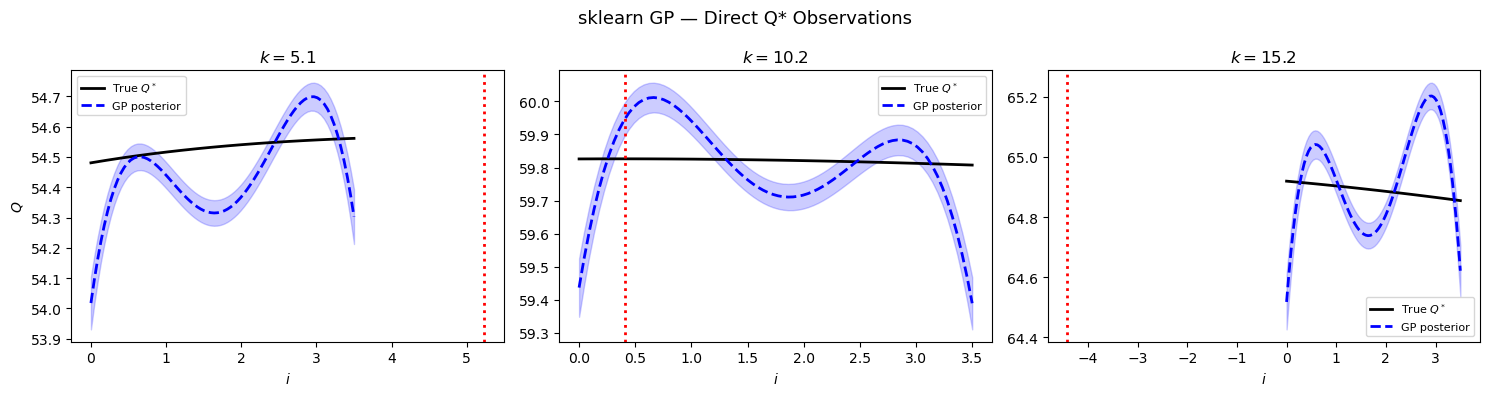

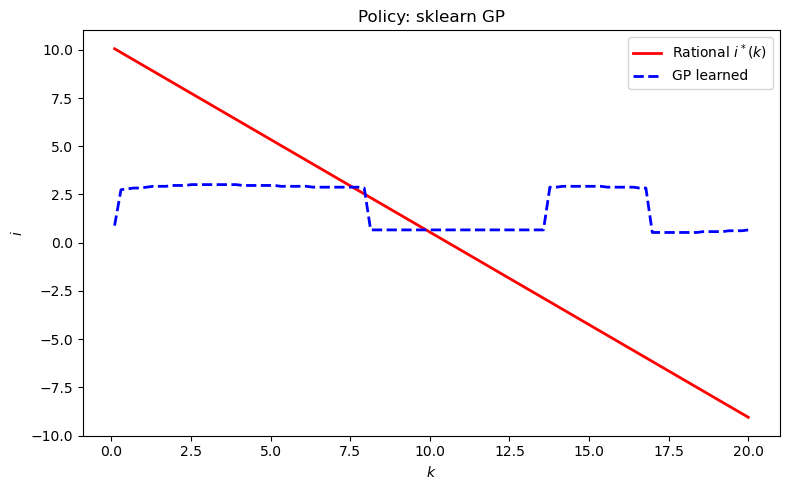

In [32]:
# %% ─── Just confirm GP works with sklearn ───────────────────────

# If scikit-learn is not installed, run this once:
# %pip install scikit-learn

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
import numpy as np
import matplotlib.pyplot as plt
from src.simulation import InvestmentParameters, InvestmentEnvironment, RationalInvestment
from scipy.interpolate import interp1d

p = InvestmentParameters(KAPPA=0.0, SIGMA_EPS=0.0)
env = InvestmentEnvironment(p)
rat = RationalInvestment(p).fit()
k_ss = rat.fixed_point()

k_grid = rat.k_grid
i_grid = np.linspace(0.0, 3.5, 80)
ev_func = interp1d(k_grid, rat.v[0, :], kind='linear', fill_value='extrapolate')

def Q_star(z, k, i):
    kp = np.clip((1 - p.DELTA) * k + i, k_grid[0], k_grid[-1])
    return env.dividend(z, k, i) + p.BETA * ev_func(kp)

Q_true = np.zeros((k_grid.size, i_grid.size))
for ik, k in enumerate(k_grid):
    for ii, iv in enumerate(i_grid):
        Q_true[ik, ii] = Q_star(1.0, k, iv)
pol_rat = np.array([rat.policy_kprime(1.0, k) - (1 - p.DELTA) * k for k in k_grid])

# %% ─── Train sklearn GP on random Q* observations ───────────────

np.random.seed(42)
N = 800

X_train = np.column_stack([
    np.ones(N),
    np.random.uniform(k_grid[0], k_grid[-1], N),
    np.random.uniform(i_grid[0], i_grid[-1], N),
])
y_train = np.array([Q_star(*x) for x in X_train]) + np.random.normal(0, 0.3, N)

kernel = ConstantKernel(4.0, constant_value_bounds="fixed") * \
         RBF(length_scale=[0.5, 5.0, 2.0], length_scale_bounds="fixed")

gp = GaussianProcessRegressor(kernel=kernel, alpha=0.3**2, optimizer=None)
gp.fit(X_train, y_train)
print("Fitted.")

# %% ─── Predict and plot ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, k_val in enumerate([k_ss * 0.5, k_ss, k_ss * 1.5]):
    ax = axes[idx]
    ik = int(np.argmin(np.abs(k_grid - k_val)))
    X_q = np.column_stack([np.ones(80), np.full(80, k_val), i_grid])
    mu, std = gp.predict(X_q, return_std=True)

    ax.plot(i_grid, Q_true[ik, :], 'k-', lw=2, label='True $Q^*$')
    ax.plot(i_grid, mu, 'b--', lw=2, label='GP posterior')
    ax.fill_between(i_grid, mu - std, mu + std, alpha=0.2, color='blue')
    ax.axvline(pol_rat[ik], color='r', ls=':', lw=2)
    ax.set_xlabel('$i$'); ax.set_title(f'$k = {k_val:.1f}$')
    if idx == 0: ax.set_ylabel('$Q$')
    ax.legend(fontsize=8)
plt.suptitle('sklearn GP — Direct Q* Observations', fontsize=13)
plt.tight_layout(); plt.show()

# policy
gp_pol = []
for k in k_grid:
    X_q = np.column_stack([np.ones(80), np.full(80, k), i_grid])
    mu, _ = gp.predict(X_q, return_std=True)
    gp_pol.append(i_grid[np.argmax(mu)])
gp_pol = np.array(gp_pol)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_grid, pol_rat, 'r-', lw=2, label='Rational $i^*(k)$')
ax.plot(k_grid, gp_pol, 'b--', lw=2, label='GP learned')
ax.set_xlabel('$k$'); ax.set_ylabel('$i$'); ax.legend()
ax.set_title('Policy: sklearn GP'); plt.tight_layout(); plt.show()

In [33]:
import numpy as np

class FirmGPTD:
    def __init__(self, beta, length_scales, sigma0_sq, sigma_n_sq, prior_mean_fn=None):
        """
        Initializes the GPTD for the firm's investment problem.
        
        Args:
            beta (float): Discount factor.
            length_scales (list or array): Length scales for [z, k, i].
            sigma0_sq (float): Variance of the GP prior (signal variance).
            sigma_n_sq (float): Variance of the observation noise.
            prior_mean_fn (callable): Function taking an array of points X 
                                      and returning the prior mean Q_0(X).
        """
        self.beta = beta
        self.length_scales = np.array(length_scales)
        self.sigma0_sq = sigma0_sq
        self.sigma_n_sq = sigma_n_sq
        self.prior_mean_fn = prior_mean_fn if prior_mean_fn else lambda x: np.zeros(x.shape[0])
        
        # History of transitions and rewards
        self.X_dec = []  # Decision points: (z_t, k_t, i_t)
        self.X_out = []  # Outcome points: (z_{t+1}, k_{t+1}, i_{t+1})
        self.y = []      # Dividends: d_t
        
        # Cached matrices for prediction
        self.alpha = None 
        self.L = None      # Cholesky factor of (G + sigma_n^2 I)

    def _rbf_kernel(self, X1, X2):
        """Standard squared-exponential kernel function."""
        # Scale inputs by length scales
        X1_scaled = X1 / self.length_scales
        X2_scaled = X2 / self.length_scales
        
        # Efficiently compute squared Euclidean distance
        sq_dist = (np.sum(X1_scaled**2, 1).reshape(-1, 1) + 
                   np.sum(X2_scaled**2, 1) - 
                   2 * np.dot(X1_scaled, X2_scaled.T))
        
        return self.sigma0_sq * np.exp(-0.5 * sq_dist)

    def add_observation(self, x_dec, x_out, reward):
        """
        Adds a single transition experience and updates the posterior.
        Note: Recomputes the full Gram matrix. For large N, use recursive updates.
        """
        self.X_dec.append(x_dec)
        self.X_out.append(x_out)
        self.y.append(reward)
        
        self._update_posterior()

    def _update_posterior(self):
        """Computes the inverse Gram matrix given all linear-functional constraints."""
        X_d = np.array(self.X_dec)
        X_o = np.array(self.X_out)
        y_vec = np.array(self.y)
        
        # 1. Evaluate the four kernel components
        K_dd = self._rbf_kernel(X_d, X_d)
        K_do = self._rbf_kernel(X_d, X_o)
        K_od = self._rbf_kernel(X_o, X_d)
        K_oo = self._rbf_kernel(X_o, X_o)
        
        # 2. Assemble the TD Gram matrix
        G = K_dd - self.beta * K_do - self.beta * K_od + (self.beta**2) * K_oo
        
        # 3. Compute prior mean differences
        m = self.prior_mean_fn(X_d) - self.beta * self.prior_mean_fn(X_o)
        
        # 4. Invert (G + sigma_n^2 * I) stably using Cholesky
        K_noisy = G + self.sigma_n_sq * np.eye(len(self.y))
        try:
            self.L = np.linalg.cholesky(K_noisy)
            # alpha = L^T \ (L \ (y - m))
            self.alpha = np.linalg.solve(self.L.T, np.linalg.solve(self.L, y_vec - m))
        except np.linalg.LinAlgError:
            # Fallback to standard solver if matrix is poorly conditioned
            self.alpha = np.linalg.solve(K_noisy, y_vec - m)

    def predict(self, X_query, return_std=False):
        """
        Queries the posterior Q-function at new candidate points.
        
        Args:
            X_query (ndarray): Array of shape (N_queries, 3) representing (z, k, i).
        Returns:
            mean (ndarray): Posterior mean at queried points.
            std (ndarray): Posterior standard deviation (if return_std=True).
        """
        X_q = np.atleast_2d(X_query)
        prior_q = self.prior_mean_fn(X_q)
        
        if len(self.y) == 0:
            return (prior_q, np.sqrt(self.sigma0_sq) * np.ones(len(X_q))) if return_std else prior_q

        X_d = np.array(self.X_dec)
        X_o = np.array(self.X_out)
        
        # Cross-covariance vector: k_*(x) = k(x_dec, x) - beta * k(x_out, x)
        K_dq = self._rbf_kernel(X_d, X_q)
        K_oq = self._rbf_kernel(X_o, X_q)
        k_star = K_dq - self.beta * K_oq  # Shape: (N_obs, N_queries)
        
        # Posterior mean
        post_mean = prior_q + np.dot(k_star.T, self.alpha)
        
        if not return_std:
            return post_mean
            
        # Posterior variance: k(x, x) - k_*^T (G + \sigma^2 I)^{-1} k_*
        K_qq = self._rbf_kernel(X_q, X_q)
        v = np.linalg.solve(self.L, k_star)
        post_var = np.diag(K_qq) - np.sum(v**2, axis=0)
        
        # Clip at 0 for numerical stability
        return post_mean, np.sqrt(np.maximum(post_var, 0))

In [34]:
# System Parameters
beta = 0.95
alpha = 0.3
delta = 0.1
kappa = 0.5
rho = 0.9
sigma_eps = 0.05

# GP Hyperparameters
length_scales = [1.0, 5.0, 2.0]  # [z, k, i]
sigma0_sq = 10.0                 # Prior variance
sigma_n_sq = 0.1                 # Noise variance for TD error

gp = FirmGPTD(beta, length_scales, sigma0_sq, sigma_n_sq)

# Initial State
z_t = 1.0
k_t = 10.0

# Action space for max_i Q(z, k, i)
i_grid = np.linspace(0.01, 3.0, 50) 

print("Starting Firm Simulation...")
for t in range(5):
    # 1. Form candidate queries to find best action for current state
    X_candidates_t = np.column_stack([
        np.full(len(i_grid), z_t),
        np.full(len(i_grid), k_t),
        i_grid
    ])
    
    # 2. Choose action i_t = argmax Q(z_t, k_t, i)
    Q_preds = gp.predict(X_candidates_t)
    i_t = i_grid[np.argmax(Q_preds)]
    
    # 3. Receive dividend and transition
    d_t = z_t * (k_t**alpha) - i_t - (kappa / 2.0) * (i_t**2 / k_t)
    k_next = (1 - delta) * k_t + i_t
    z_next = np.exp(rho * np.log(z_t) + np.random.normal(0, sigma_eps))
    
    # 4. Find the best guess for next period's action (The Bootstrapping step)
    X_candidates_next = np.column_stack([
        np.full(len(i_grid), z_next),
        np.full(len(i_grid), k_next),
        i_grid
    ])
    Q_preds_next = gp.predict(X_candidates_next)
    i_next = i_grid[np.argmax(Q_preds_next)]
    
    # 5. Compile decision point and outcome point, then update GP
    x_dec = np.array([z_t, k_t, i_t])
    x_out = np.array([z_next, k_next, i_next])
    
    print(f"Period {t}: State({z_t:.2f}, {k_t:.2f}) -> Took Action i={i_t:.2f}, Reward={d_t:.2f}")
    
    gp.add_observation(x_dec, x_out, d_t)
    
    # Advance to next period
    z_t, k_t = z_next, k_next

print("\nSimulation complete. The GP has learned from", len(gp.y), "TD observations.")

Starting Firm Simulation...
Period 0: State(1.00, 10.00) -> Took Action i=0.01, Reward=1.99
Period 1: State(0.97, 9.01) -> Took Action i=0.01, Reward=1.87
Period 2: State(0.98, 8.12) -> Took Action i=0.01, Reward=1.83
Period 3: State(0.95, 7.32) -> Took Action i=0.01, Reward=1.71
Period 4: State(1.01, 6.60) -> Took Action i=3.00, Reward=-1.57

Simulation complete. The GP has learned from 5 TD observations.


In [35]:
import numpy as np

class OnlineFirmGPTD:
    def __init__(self, beta, length_scales, sigma0_sq, sigma_n_sq, prior_mean_fn=None):
        self.beta = beta
        self.length_scales = np.array(length_scales)
        self.sigma0_sq = sigma0_sq
        self.sigma_n_sq = sigma_n_sq
        self.prior_mean_fn = prior_mean_fn if prior_mean_fn else lambda x: np.zeros(x.shape[0])
        
        # History
        self.X_dec = []
        self.X_out = []
        self.Y = []
        
        # O(N^2) Recursive updating components
        self.C_inv = np.empty((0, 0))  # Inverse Gram matrix
        self.alpha = np.empty((0,))    # Weights for the mean prediction
        
    def _kernel(self, X1, X2):
        """Standard Automatic Relevance Determination (ARD) RBF Kernel."""
        X1_scaled = np.atleast_2d(X1) / self.length_scales
        X2_scaled = np.atleast_2d(X2) / self.length_scales
        sq_dist = (np.sum(X1_scaled**2, 1).reshape(-1, 1) + 
                   np.sum(X2_scaled**2, 1) - 
                   2 * np.dot(X1_scaled, X2_scaled.T))
        return self.sigma0_sq * np.exp(-0.5 * sq_dist)

    def _functional_cov(self, x_dec_new, x_out_new, X_dec_old, X_out_old):
        """Computes covariance between a new TD functional and old TD functionals."""
        k_dd = self._kernel(x_dec_new, X_dec_old)
        k_do = self._kernel(x_dec_new, X_out_old)
        k_od = self._kernel(x_out_new, X_dec_old)
        k_oo = self._kernel(x_out_new, X_out_old)
        return k_dd - self.beta * k_do - self.beta * k_od + (self.beta**2) * k_oo

    def add_observation(self, x_dec, x_out, reward):
        """
        Performs the O(N^2) Bayesian update using the Schur complement.
        """
        x_dec = np.atleast_2d(x_dec)
        x_out = np.atleast_2d(x_out)
        
        # Prior mean of the observation
        m_new = self.prior_mean_fn(x_dec)[0] - self.beta * self.prior_mean_fn(x_out)[0]
        y_centered = reward - m_new
        
        if len(self.Y) == 0:
            # First observation initialization
            v_self = self._functional_cov(x_dec, x_out, x_dec, x_out)[0, 0]
            self.C_inv = np.array([[1.0 / (v_self + self.sigma_n_sq)]])
            self.alpha = self.C_inv @ np.array([y_centered])
            
            self.X_dec = x_dec
            self.X_out = x_out
            self.Y = np.array([reward])
            return

        # 1. Covariance between new observation and all history
        v = self._functional_cov(x_dec, x_out, self.X_dec, self.X_out).T  # Shape: (N, 1)
        
        # 2. Variance of the new observation
        w = self._functional_cov(x_dec, x_out, x_dec, x_out)[0, 0] + self.sigma_n_sq
        
        # 3. Schur complement update for the inverse Gram matrix C_inv
        q = self.C_inv @ v
        S = w - (v.T @ q)[0, 0]  # Scalar Schur complement
        
        # Construct new block matrix
        top_left = self.C_inv + (q @ q.T) / S
        top_right = -q / S
        bottom_left = -q.T / S
        bottom_right = np.array([[1.0 / S]])
        
        self.C_inv = np.block([
            [top_left, top_right],
            [bottom_left, bottom_right]
        ])
        
        # 4. Append data and update alpha
        self.X_dec = np.vstack([self.X_dec, x_dec])
        self.X_out = np.vstack([self.X_out, x_out])
        self.Y = np.append(self.Y, reward)
        
        # Recompute alpha vector: C_inv * (Y - M)
        M = self.prior_mean_fn(self.X_dec) - self.beta * self.prior_mean_fn(self.X_out)
        self.alpha = self.C_inv @ (self.Y - M)

    def predict(self, X_query, return_std=False):
        """
        Predicts Q*(X_query) based on the accumulated linear functional observations.
        """
        X_q = np.atleast_2d(X_query)
        prior_q = self.prior_mean_fn(X_q)
        
        if len(self.Y) == 0:
            return (prior_q, np.sqrt(self.sigma0_sq) * np.ones(len(X_q))) if return_std else prior_q

        # Cross-covariance between query points and TD functionals
        K_dq = self._kernel(self.X_dec, X_q)
        K_oq = self._kernel(self.X_out, X_q)
        k_star = K_dq - self.beta * K_oq  # Shape: (N, N_queries)
        
        # Posterior Mean
        post_mean = prior_q + k_star.T @ self.alpha
        
        if not return_std:
            return post_mean
            
        # Posterior Variance
        K_qq_diag = np.full(len(X_q), self.sigma0_sq) # Diagonal of k(X_q, X_q)
        # Efficient quadratic form: diag(k_star^T * C_inv * k_star)
        variance_reduction = np.sum(k_star * (self.C_inv @ k_star), axis=0)
        post_var = K_qq_diag - variance_reduction
        
        return post_mean, np.sqrt(np.maximum(post_var, 0))

In [37]:
# Test configuration
np.random.seed(42)
beta = 0.95
length_scales = [1.0, 5.0, 2.0]  # [z, k, i]
sigma0_sq = 1.0                  # Prior variance
sigma_n_sq = 0.01                # Observation noise

gp = OnlineFirmGPTD(beta, length_scales, sigma0_sq, sigma_n_sq)

# Simulate 5 periods of experience-based learning
print("--- Beginning Experience-Based Learning ---\n")

z_t, k_t = 1.0, 10.0
for t in range(1, 50):
    # Agent picks an action (randomly for this test)
    i_t = np.random.uniform(0.5, 2.0)
    
    # Environment transitions
    z_next = z_t * np.exp(np.random.normal(0, 0.1)) # Productivity shock
    k_next = 0.9 * k_t + i_t                        # Capital transition
    
    # Observe dividend (payoff)
    d_t = z_t * (k_t**0.3) - i_t - 0.5 * (i_t**2 / k_t)
    
    # Evaluate greedy continuation (assuming 3 discrete choices for simplicity)
    candidate_actions = np.array([0.5, 1.0, 1.5])
    X_candidates = np.column_stack([
        np.full(3, z_next), np.full(3, k_next), candidate_actions
    ])
    
    # Query posterior for intermediate beliefs
    Q_preds = gp.predict(X_candidates)
    i_next_greedy = candidate_actions[np.argmax(Q_preds)]
    
    # The decision point and the outcome point
    x_dec = np.array([z_t, k_t, i_t])
    x_out = np.array([z_next, k_next, i_next_greedy])
    
    # Before update: What does the GP think of the action we just took?
    q_before = gp.predict(x_dec)[0]
    
    # Apply Empirical Learning Update
    gp.add_observation(x_dec, x_out, d_t)
    
    # After update: How did beliefs shift?
    q_after = gp.predict(x_dec)[0]
    
    print(f"Period {t}:")
    print(f"  Observed Dividend: {d_t:.3f}")
    print(f"  Q-value at (z_t, k_t, i_t) BEFORE update: {q_before:.3f}")
    print(f"  Q-value at (z_t, k_t, i_t) AFTER  update: {q_after:.3f}")
    print("-" * 45)
    
    z_t, k_t = z_next, k_next

print(f"Final Inverse Gram Matrix Shape: {gp.C_inv.shape}")

--- Beginning Experience-Based Learning ---

Period 1:
  Observed Dividend: 0.877
  Q-value at (z_t, k_t, i_t) BEFORE update: 0.000
  Q-value at (z_t, k_t, i_t) AFTER  update: 0.837
---------------------------------------------
Period 2:
  Observed Dividend: 1.028
  Q-value at (z_t, k_t, i_t) BEFORE update: 0.343
  Q-value at (z_t, k_t, i_t) AFTER  update: 4.881
---------------------------------------------
Period 3:
  Observed Dividend: 1.227
  Q-value at (z_t, k_t, i_t) BEFORE update: 4.878
  Q-value at (z_t, k_t, i_t) AFTER  update: 5.801
---------------------------------------------
Period 4:
  Observed Dividend: 0.168
  Q-value at (z_t, k_t, i_t) BEFORE update: 4.834
  Q-value at (z_t, k_t, i_t) AFTER  update: 7.222
---------------------------------------------
Period 5:
  Observed Dividend: 1.553
  Q-value at (z_t, k_t, i_t) BEFORE update: 7.695
  Q-value at (z_t, k_t, i_t) AFTER  update: 9.004
---------------------------------------------
Period 6:
  Observed Dividend: 1.145
  Q

In [38]:
# %% ─── Test GP Convergence at Steady State ───────────────────────

# 1. Derive discount factor from interest rate
beta = 1.0 / (1.0 + p.R)

# 2. Initialize the GP
# Using a high prior variance (sigma0_sq) to allow it to learn, 
# and very low noise (sigma_n_sq) since the steady state is deterministic.
length_scales = [1.0, 5.0, 2.0]  # [z, k, i]
gp = OnlineFirmGPTD(
    beta=beta, 
    length_scales=length_scales, 
    sigma0_sq=100.0, 
    sigma_n_sq=1e-4
)

# 3. Define the single fixed-point tuple
z_ss = 1.0
x_ss = np.array([z_ss, k_ss, i_ss])

# Theoretical target: D + beta * D + beta^2 * D ... = D / (1 - beta)
true_q_ss = d_ss / (1 - beta)

print(f"Target Theoretical Q*: {true_q_ss:.4f}\n")
print("Injecting steady-state experience into GP...")

# 4. Repeatedly observe the exact same transition
for t in range(1, 11):
    # The firm is at x_ss, takes action i_ss, gets d_ss, and expects to take i_ss tomorrow.
    # Therefore, x_dec = x_ss and x_out = x_ss
    gp.add_observation(x_dec=x_ss, x_out=x_ss, reward=d_ss)
    
    # Query the posterior at the steady state
    q_pred = gp.predict(x_ss)[0]
    
    error = np.abs(true_q_ss - q_pred)
    print(f"Period {t:2d} | GP Predicted Q: {q_pred:.4f} | Absolute Error: {error:.4f}")

Target Theoretical Q*: 56.0300

Injecting steady-state experience into GP...
Period  1 | GP Predicted Q: 55.9641 | Absolute Error: 0.0660
Period  2 | GP Predicted Q: 55.9970 | Absolute Error: 0.0330
Period  3 | GP Predicted Q: 56.0080 | Absolute Error: 0.0220
Period  4 | GP Predicted Q: 56.0135 | Absolute Error: 0.0165
Period  5 | GP Predicted Q: 56.0168 | Absolute Error: 0.0132
Period  6 | GP Predicted Q: 56.0190 | Absolute Error: 0.0110
Period  7 | GP Predicted Q: 56.0206 | Absolute Error: 0.0094
Period  8 | GP Predicted Q: 56.0218 | Absolute Error: 0.0083
Period  9 | GP Predicted Q: 56.0227 | Absolute Error: 0.0073
Period 10 | GP Predicted Q: 56.0234 | Absolute Error: 0.0066


In [ ]:
@dataclass
class GPBeliefParameters:
    # RBF kernel hyperparameters
    sigma0: float = 1.0       # prior signal std
    lz: float = 0.5           # lengthscale in z
    lk: float = 3.0           # lengthscale in k
    li: float = 1.0           # lengthscale in i (investment)
    sigma_n: float = 0.01     # observation noise std (required for stability)

class OnlineFirmGPTD:
    def __init__(self, env_params: InvestmentParameters, gp_params: GPBeliefParameters, prior_mean_fn=None):
        # 1. Environment Parameters
        self.env_params = env_params
        self.gp_params = gp_params
        
        # 2. GP Hyperparameters
        self.length_scales = np.array([gp_params.lz, gp_params.lk, gp_params.li])
        self.sigma0_sq = gp_params.sigma0 ** 2
        self.sigma_n_sq = gp_params.sigma_n ** 2 # noise variance to allow matrix inversion
        
        # 3. Prior Mean Setup
        self.prior_mean_fn = prior_mean_fn if prior_mean_fn else lambda x: np.zeros(x.shape[0])
        
        # 4. History Storage
        self.X_dec = np.empty((0, 3))
        self.X_out = np.empty((0, 3))
        self.Y = np.empty(0)
        
        # 5. Recursive Inverse Matrices
        self.C_inv = np.empty((0, 0))
        self.alpha = np.empty((0,))   # The weights vector for predictions

    def _kernel(self, X1, X2):
        """Calculates the RBF kernel matrix between two sets of points.
        Points must be (z, k, i) tuples.
        """
        X1_scaled = np.atleast_2d(X1) / self.length_scales
        X2_scaled = np.atleast_2d(X2) / self.length_scales
        
        # Efficient vectorized squared Euclidean distance
        sq_dist = (np.sum(X1_scaled**2, 1).reshape(-1, 1) + 
                   np.sum(X2_scaled**2, 1) - 
                   2 * np.dot(X1_scaled, X2_scaled.T))
        
        return self.sigma0_sq * np.exp(-0.5 * sq_dist)
    
    def _functional_cov(self, X_dec_1, X_out_1, X_dec_2, X_out_2):
        """
        Evaluates the 4-term covariance between two sets of TD transitions.
        Each transition is defined by a decision point and an outcome point.
        """
        beta = self.env_params.BETA
        
        k_dd = self._kernel(X_dec_1, X_dec_2)
        k_do = self._kernel(X_dec_1, X_out_2)
        k_od = self._kernel(X_out_1, X_dec_2)
        k_oo = self._kernel(X_out_1, X_out_2)
        
        return k_dd - beta * k_do - beta * k_od + (beta**2) * k_oo
    
    def _first_observation(self, x_dec, x_out, dividend):
        """Initializes the GP memory with the first empirical experience."""
        # Calculate novelty of the first point
        v_self = self._functional_cov(x_dec, x_out, x_dec, x_out)[0, 0]
        self.C_inv = np.array([[1.0 / (v_self + self.sigma_n_sq)]])
        
        # Store state
        self.X_dec = x_dec # Already forced to 2D in add_observation
        self.X_out = x_out
        self.Y = np.array([dividend])
        
        # Initial surprise (Innovation)
        m_0 = np.atleast_1d(self.prior_mean_fn(x_dec))[0] - self.env_params.BETA * np.atleast_1d(self.prior_mean_fn(x_out))[0]
        self.alpha = self.C_inv @ np.array([dividend - m_0])
    

    def add_observation(self, x_dec, x_out, dividend):
        """
        Incorporates a new Temporal Difference observation and recursively 
        updates the inverse Gram matrix and weights.
        """
        beta = self.env_params.BETA
        
        # Ensure correct shape (1, 3)
        x_dec = np.atleast_2d(x_dec)
        x_out = np.atleast_2d(x_out)
        
        if len(self.Y) == 0:
            self._first_observation(x_dec, x_out, dividend)
            return
        
        v = self._functional_cov(x_dec, x_out, self.X_dec, self.X_out).T # covariance between new obs and history: shape (N, 1)
        w = self._functional_cov(x_dec, x_out, x_dec, x_out)[0, 0] + self.sigma_n_sq # variance of new obs + noise
        q = self.C_inv @ v
        S = w - (v.T @ q)[0, 0] # schur complement scalar
        
        # Build the new block matrix
        top_left = self.C_inv + (q @ q.T) / S
        top_right = -q / S
        bottom_left = -q.T / S
        bottom_right = np.array([[1.0 / S]])
        
        self.C_inv = np.block([
            [top_left, top_right],
            [bottom_left, bottom_right]
        ])

        # Update History
        self.X_dec = np.vstack([self.X_dec, x_dec])
        self.X_out = np.vstack([self.X_out, x_out])
        self.Y = np.append(self.Y, dividend)
        
        # Update Alpha (Batch approach - ensures numerical stability)
        M = self.prior_mean_fn(self.X_dec) - self.env_params.BETA * self.prior_mean_fn(self.X_out)
        self.alpha = self.C_inv @ (self.Y - M)

    def _predict_no_observations(self, X_query, return_std):
        """Returns the prior mean and variance when no observations have been made."""
        prior_q = self.prior_mean_fn(X_query)
        if return_std:
            return prior_q, np.sqrt(self.sigma0_sq) * np.ones(len(X_query))
        return prior_q

    def predict(self, X_query, return_std=False):
        """Predicts Q*(X_query) based on the accumulated linear functional observations."""
        X_q = np.atleast_2d(X_query)
        prior_q = self.prior_mean_fn(X_q) # Prior mean at query points
        
        # base case - if no observations, return prior mean and prior std
        if len(self.Y) == 0:
            return self._predict_no_observations(X_q, return_std)

        # Cross-covariance between query points and TD functionals
        K_dq = self._kernel(self.X_dec, X_q)
        K_oq = self._kernel(self.X_out, X_q)
        k_star = K_dq - self.env_params.BETA * K_oq # Shape: (N, N_queries)
        
        # Posterior Mean
        post_mean = prior_q + k_star.T @ self.alpha
        
        if not return_std:
            return post_mean
            
        # Posterior Variance
        K_qq_diag = np.full(len(X_q), self.sigma0_sq) # Diagonal of k(X_q, X_q)
        # Efficient quadratic form: diag(k_star^T * C_inv * k_star)
        variance_reduction = np.sum(k_star * (self.C_inv @ k_star), axis=0)
        post_var = K_qq_diag - variance_reduction
        
        return post_mean, np.sqrt(np.maximum(post_var, 0))